In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
# user functions
import UserMetricsFunctions as umf

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Dataset

In [2]:
# import data
X = pd.read_pickle("../Data/X_dependent.pkl")
y = pd.read_pickle("../Data/y_label.pkl")

In [3]:
X.shape, y.shape

((9835, 249), (9835,))

### Split Dataset

In [4]:
from sklearn.model_selection import train_test_split

# mapping values
y = y.map({'Living': True, 'Dead': False})

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [5]:
from sklearn.preprocessing import MinMaxScaler

# initialize MinMaxScaler
scale = MinMaxScaler(feature_range=(1, 10))

# fit
fitScale = scale.fit(X_train)

# transform
X_train_scale = fitScale.transform(X_train)
X_test_scale = fitScale.transform(X_test)

### Select K Best

In [6]:
# import lfeature selection ibrary & functions
from sklearn.feature_selection import SelectKBest, f_classif, chi2, VarianceThreshold, mutual_info_classif

def selectKClassif(Xdata, ydata, K='all', function='f_classif'):
    """
    This function selects the most relevant features for classification tasks using statistical tests provided 
    by SelectKBest and removes constant features from the dataset. It also returns detailed information on the 
    chosen features, including their scores and p-values.
    """
    # remove constant features
    constanFilter = VarianceThreshold(threshold=0)  # removes features with zero variance
    X_data = constanFilter.fit_transform(Xdata)

    # update feature names after removing constant features
    remaining_feature_names = Xdata.columns[constanFilter.get_support(indices=True)]
    
    # Step 3: Apply SelectKBest with F-classif
    selector = SelectKBest(score_func=eval(function), k=K)
    X_new = selector.fit_transform(X_data, ydata)

    # update feature names to reflect remaining, selected features
    selected_List = [remaining_feature_names[i] for i in selector.get_support(indices=True)]
    
    # create a DataFrame with selected features and their F-scores
    feature_scores = selector.scores_

    # access the p-values
    p_values = selector.pvalues_

    # create DataFrame
    feature_scores_df = pd.DataFrame({
        'Feature': remaining_feature_names,
        'Score': feature_scores,
        'p_value': p_values
    }).sort_values(by='Score', ascending=False)

    # get ONLY selected Features
    DF_selected = feature_scores_df[feature_scores_df.Feature.isin(selected_List)]
    
    # retrun
    return DF_selected

### RandomForestClassifier
- `Random Forest`
    - Type: Ensemble learning (bagging)
    - Mechanism: Constructs multiple decision trees during training and outputs the mode of the classes (classification) or mean prediction (regression) of the individual trees.
    - Pros: Handles high-dimensional data well, reduces overfitting, robust to noise.
    - Cons: Less interpretable, can be computationally intensive.

In [7]:
from sklearn.ensemble import RandomForestClassifier
# function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

# the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# grid search Hyperparameters Random Forest Classfiier
parameters = {
    'n_estimators': [100, 300, 500],
    'min_samples_split': [30, 40, 50],
    'min_samples_leaf': [8, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 7]
}


# Initialize Model with class weights
rfc_param = {'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
model = RandomForestClassifier(**rfc_param)

# CV with grid search for Hyper-Parameter tuning
rfc_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score = 'accuracy')

# best model
model = rfc_fit.best_estimator_

CV accuracy: 0.766 +/- 0.009


In [8]:
print(model)

RandomForestClassifier(class_weight={False: 1.109732016925247,
                                     True: 0.9100161924589405},
                       max_depth=7, min_samples_leaf=10, min_samples_split=40,
                       random_state=1776)


#### Feature Importance Plot

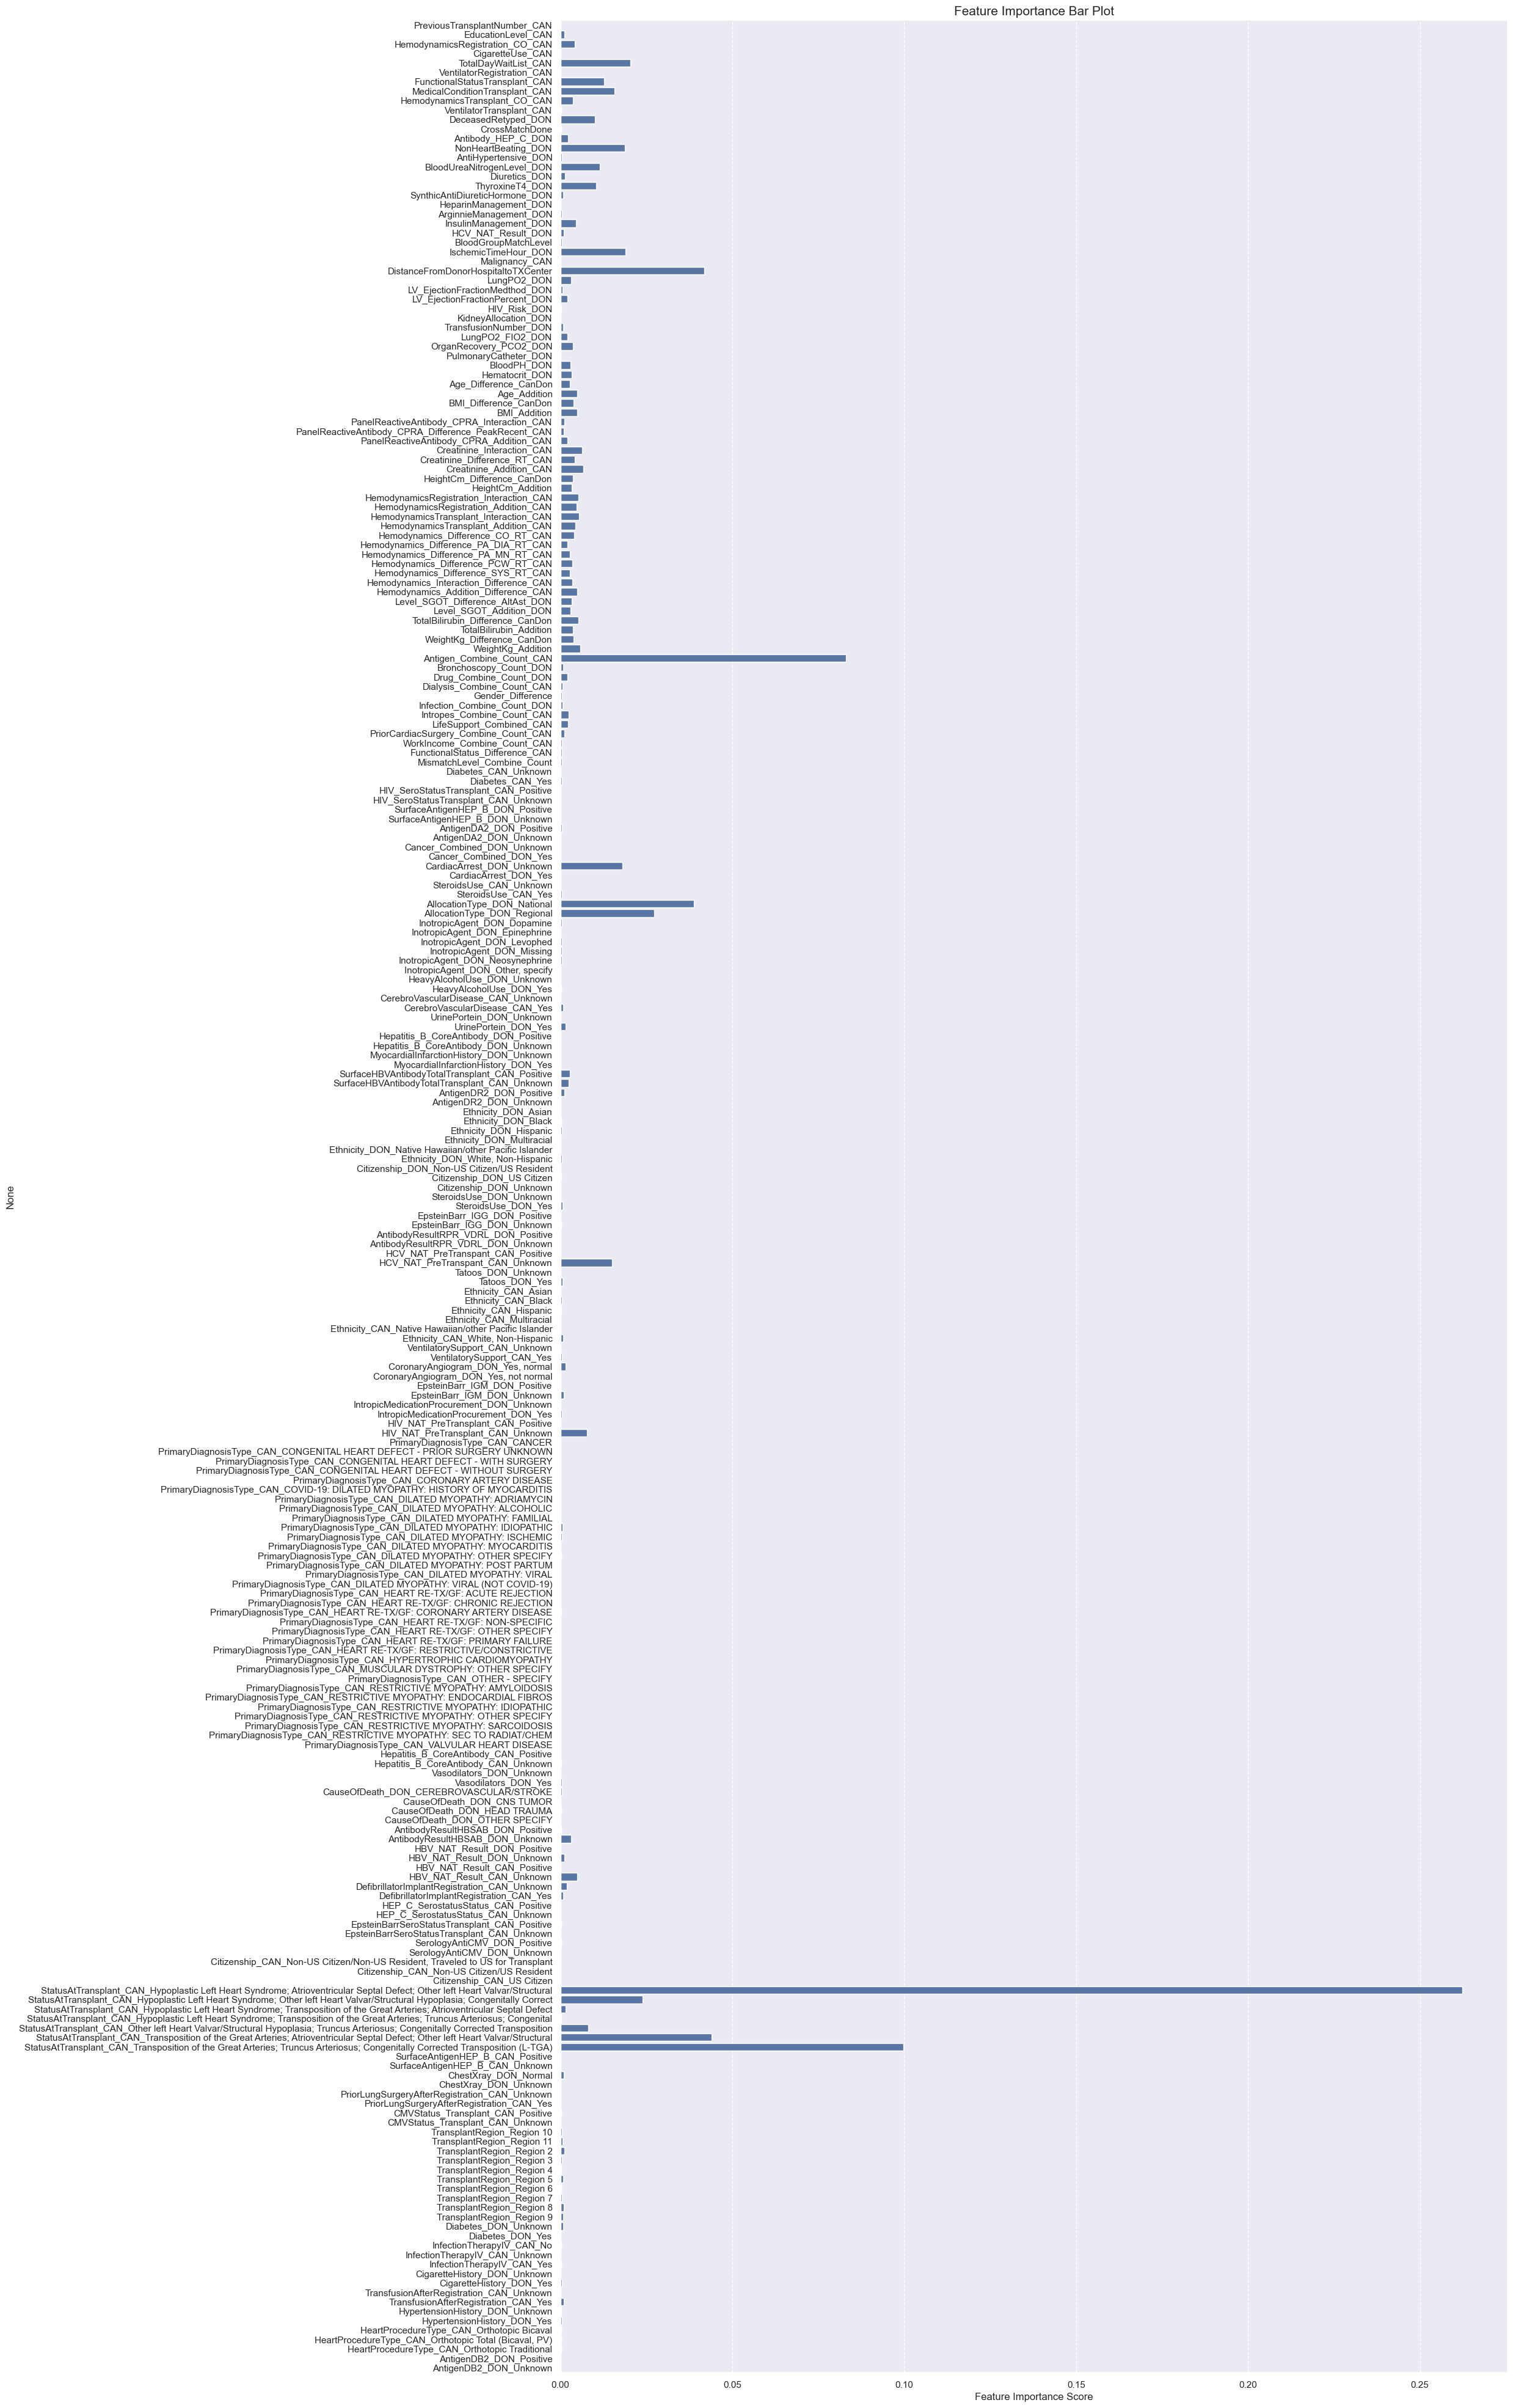

In [9]:
df_rfc = umf.plotFeatureImportance(model, pd.DataFrame(X_train_scale, columns=X_train.columns.to_list()),figsize=(20,50))

In [10]:
df_rfc.sort_values(by='Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.262311
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.099812
Antigen_Combine_Count_CAN,0.083021
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.044037
DistanceFromDonorHospitaltoTXCenter,0.041838
AllocationType_DON_National,0.038793
AllocationType_DON_Regional,0.027243
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.023890
TotalDayWaitList_CAN,0.020248
IschemicTimeHour_DON,0.018971


#### Metrics

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.72      0.87      0.79      3545
        True       0.87      0.72      0.79      4323

    accuracy                           0.79      7868
   macro avg       0.79      0.79      0.79      7868
weighted avg       0.80      0.79      0.79      7868



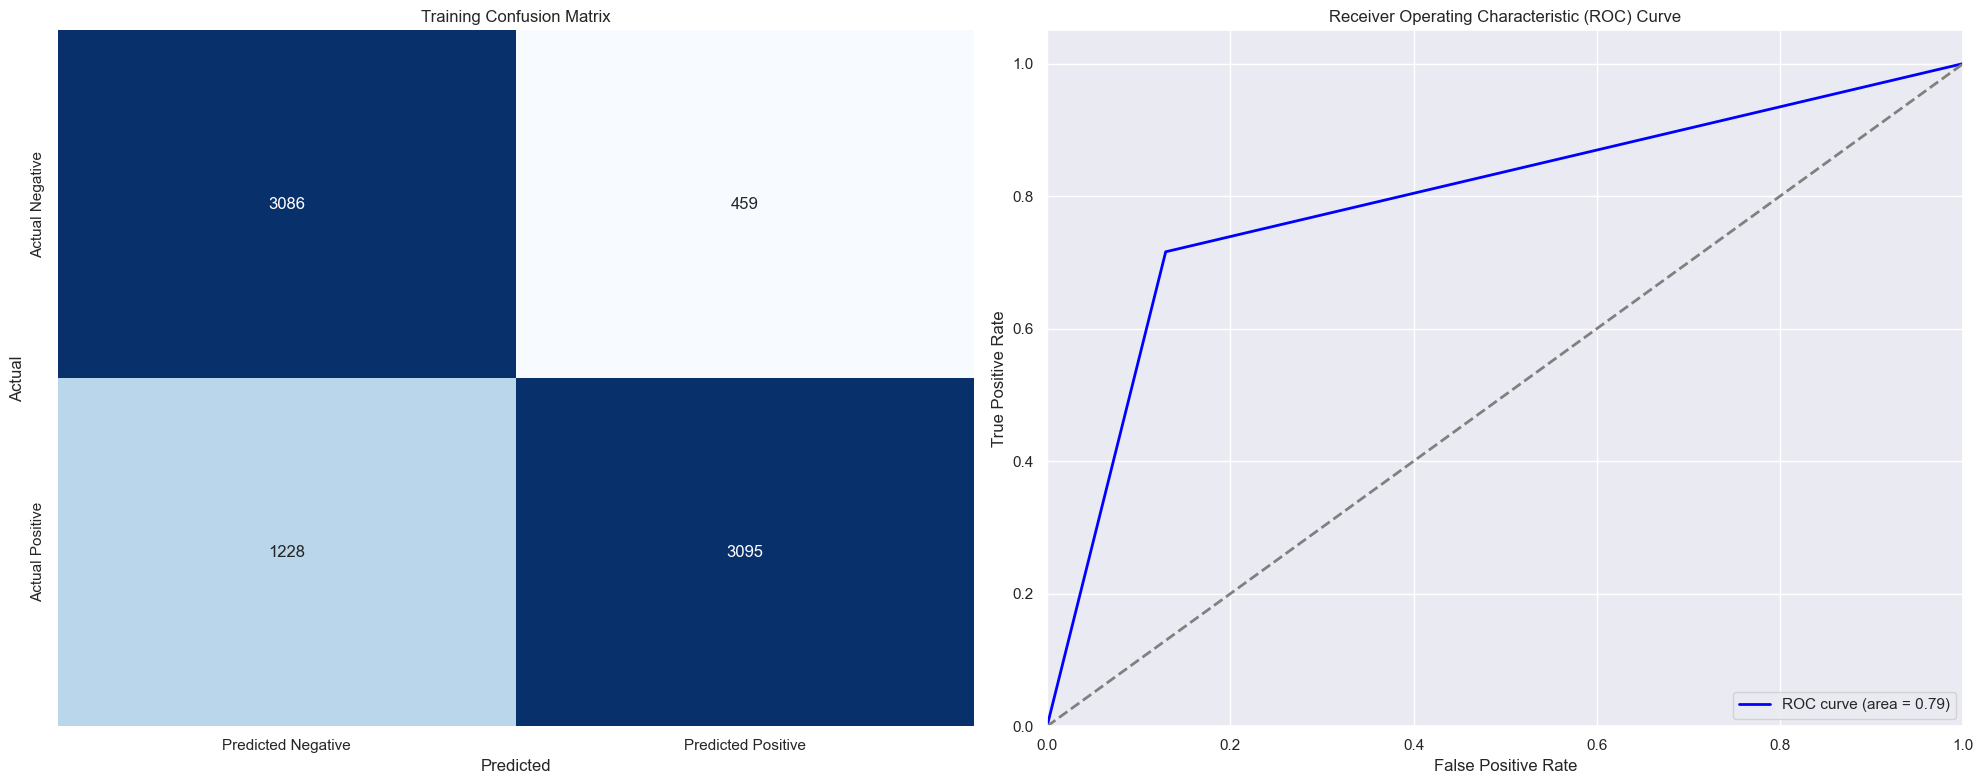

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.77955,0.87085,0.870522,0.79323


In [11]:
# initialize variables
Algorithm = 'RandomForestClassifier'
Desc = 'RandomForestClassifier - Grid Search - All Features'
Model = 'rfc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.69      0.86      0.77       886
        True       0.86      0.69      0.76      1081

    accuracy                           0.77      1967
   macro avg       0.78      0.77      0.77      1967
weighted avg       0.78      0.77      0.77      1967



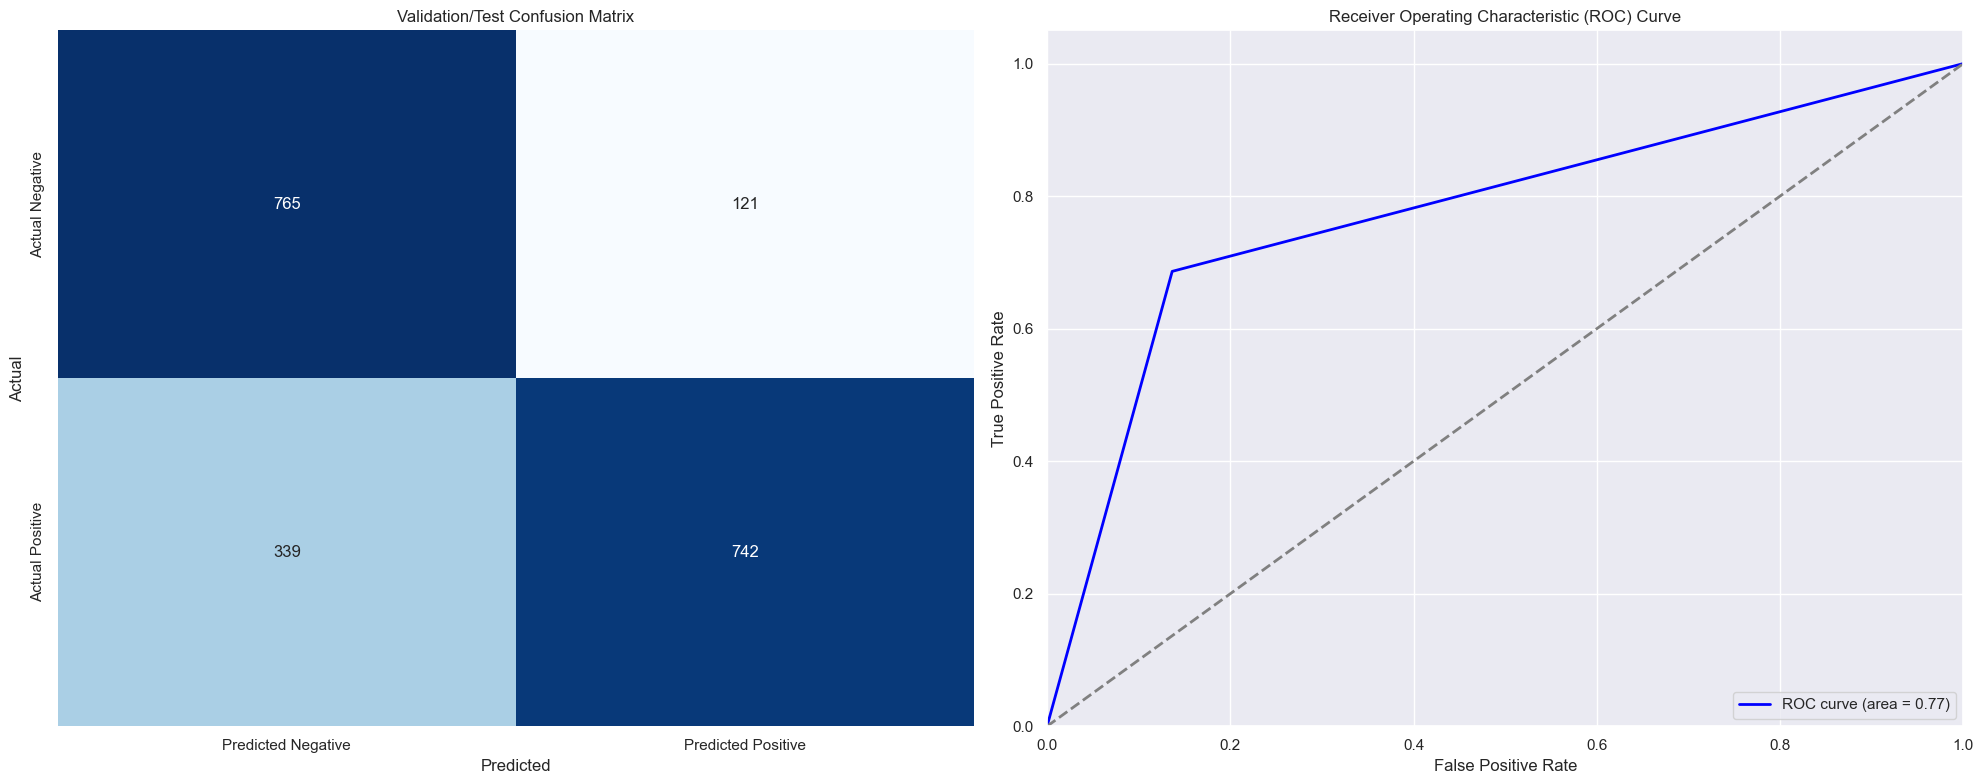

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916


In [12]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, df_classfication)
df_classfication

### LogisticRegression
- `Logistic Regression`
    - Type: Parametric, linear model
    - Mechanism: Estimates the probability that a given input belongs to a certain class using a logistic function.
    - Pros: Interpretable, efficient, works well with linearly separable data.
    - Cons: Assumes linearity, not suitable for complex relationships.

In [13]:
# import library
from sklearn.linear_model import LogisticRegression

# define the hyperparameter grid to search
parameters = dict(
C = list(np.round(np.linspace(0.01, 5, 20),2))
)

# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate LogisticRegression Classifier
model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
lrc_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = lrc_fit.best_estimator_

CV accuracy: 0.770 +/- 0.009


In [14]:
print(model)

LogisticRegression(C=1.32,
                   class_weight={False: 1.109732016925247,
                                 True: 0.9100161924589405},
                   max_iter=10000, random_state=1776)


In [15]:
# # feature importance & plot
# lrc_df = umf.LogisticFeatureImportance(model, figsize=(30,30), fontsize=8)

#### Metrics

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.72      0.86      0.78      3545
        True       0.86      0.72      0.79      4323

    accuracy                           0.78      7868
   macro avg       0.79      0.79      0.78      7868
weighted avg       0.80      0.78      0.78      7868



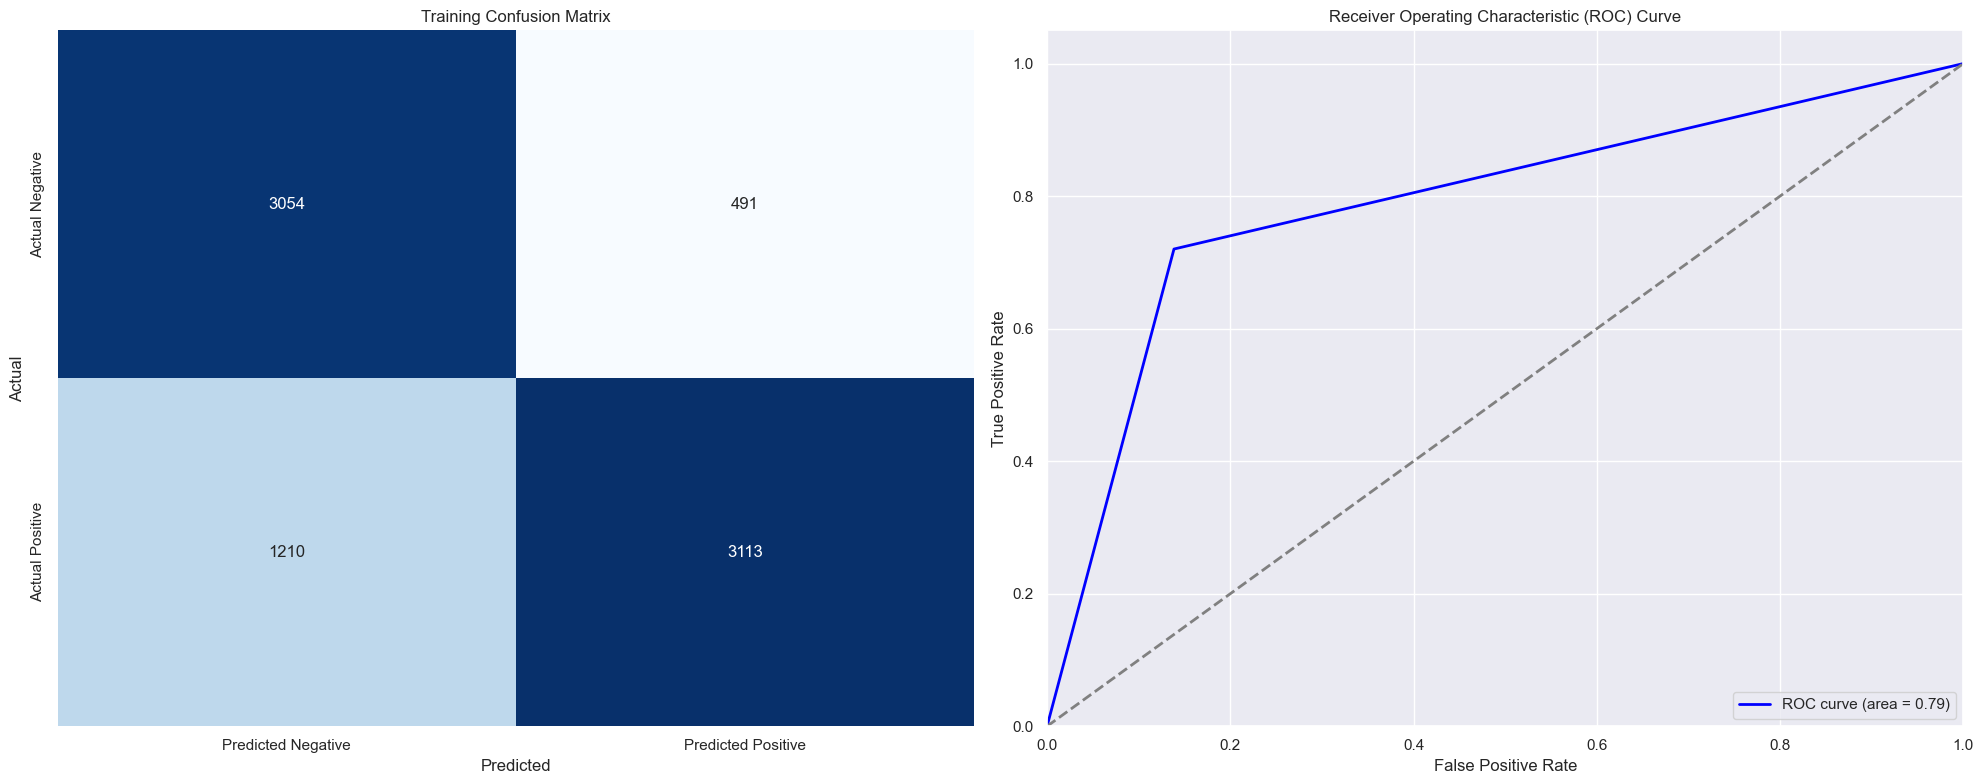

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798


In [16]:
# initialize variables
Algorithm = 'LogisticRegression'
Desc = 'LogisticRegression - Grid Search - All Features'
Model = 'lrc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.69      0.85      0.76       886
        True       0.85      0.69      0.76      1081

    accuracy                           0.76      1967
   macro avg       0.77      0.77      0.76      1967
weighted avg       0.78      0.76      0.76      1967



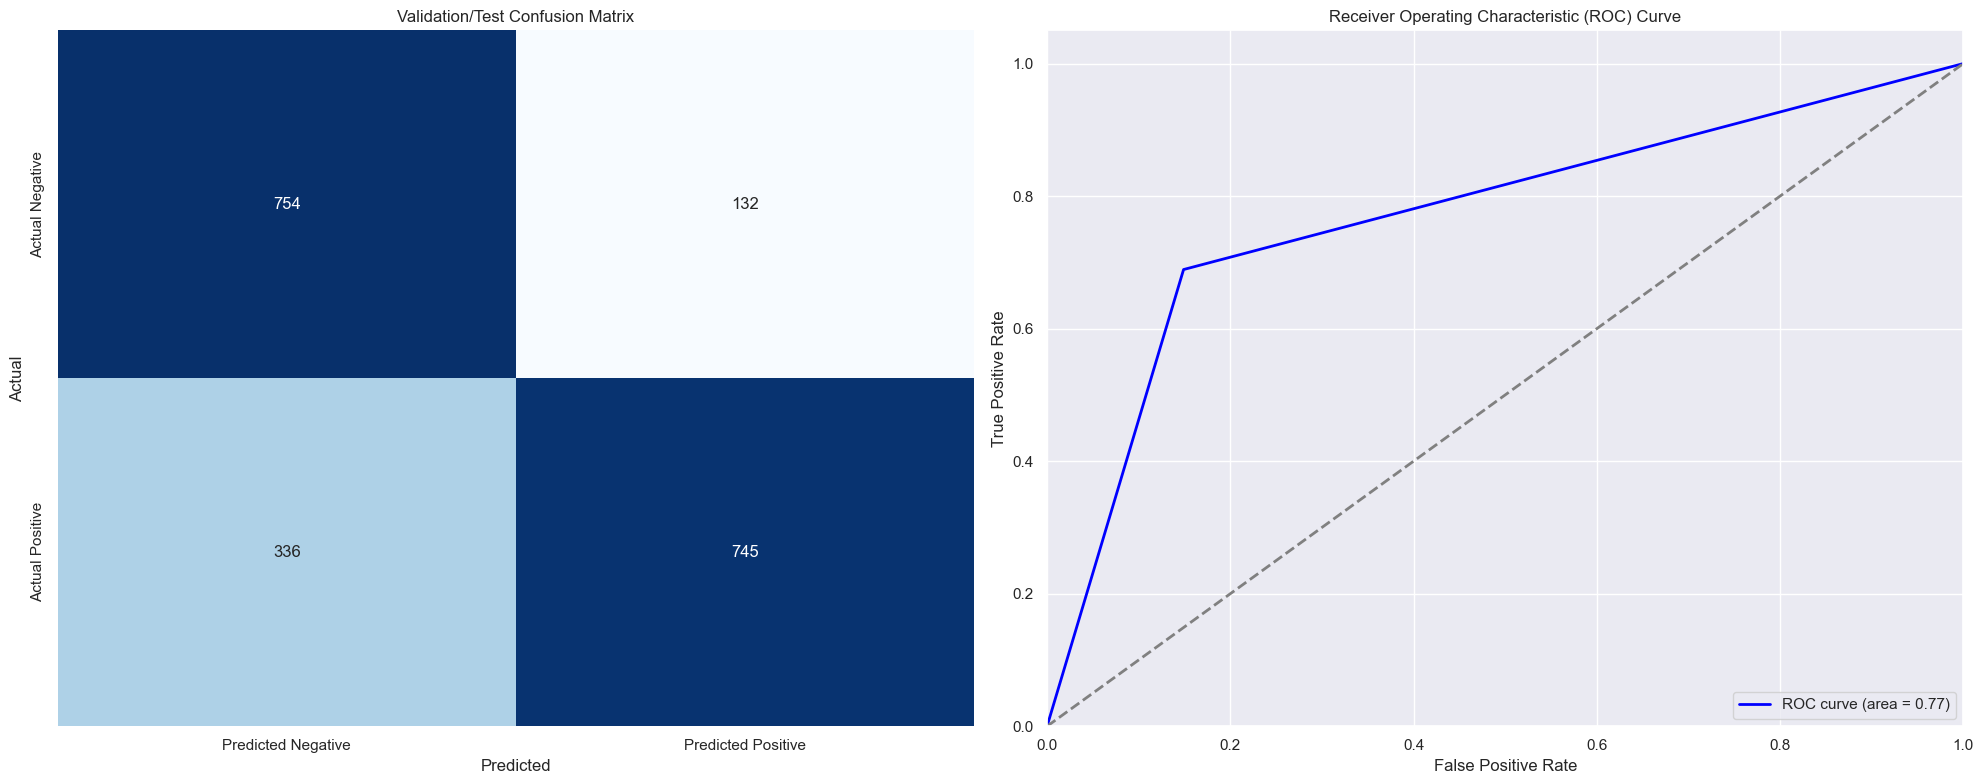

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096


In [17]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### XGBClassifier
- XG Boost
    - Type: Boosting
    - Mechanism: Sequentially builds trees, where each new tree corrects the errors of the previous ones. Uses gradient boosting to optimize the model.
    - Pros: High performance and accuracy and includes regularization (L1 and L2) to prevent overfitting.
    - Cons: More complex and harder to tune compared to Random Forest while it can be computationally intensive, especially with large datasets.

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [18]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the hyperparameter grid to search
parameters = dict(
n_estimators = [50, 100, 200],
max_depth = [3, 5],
learning_rate = [0.01, 0.05, 0.1],
subsample = [0.4, 0.7],
gamma = [0.8, 1, 5]   # regularization term that controls the minimum loss reduction required to make a split at a node.
)

# Base Model
xgb_param = {'scale_pos_weight': scale_pos_weight, 'n_jobs': -1, 'random_state': RANDOM_STATE}

# instantiate XGB Classifier
model = XGBClassifier(**xgb_param)

# CV with grid search for Hyper-Parameter tuning
xgb_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = xgb_fit.best_estimator_

CV accuracy: 0.778 +/- 0.010


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [19]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.8, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=1776, ...)


#### Feature Importance

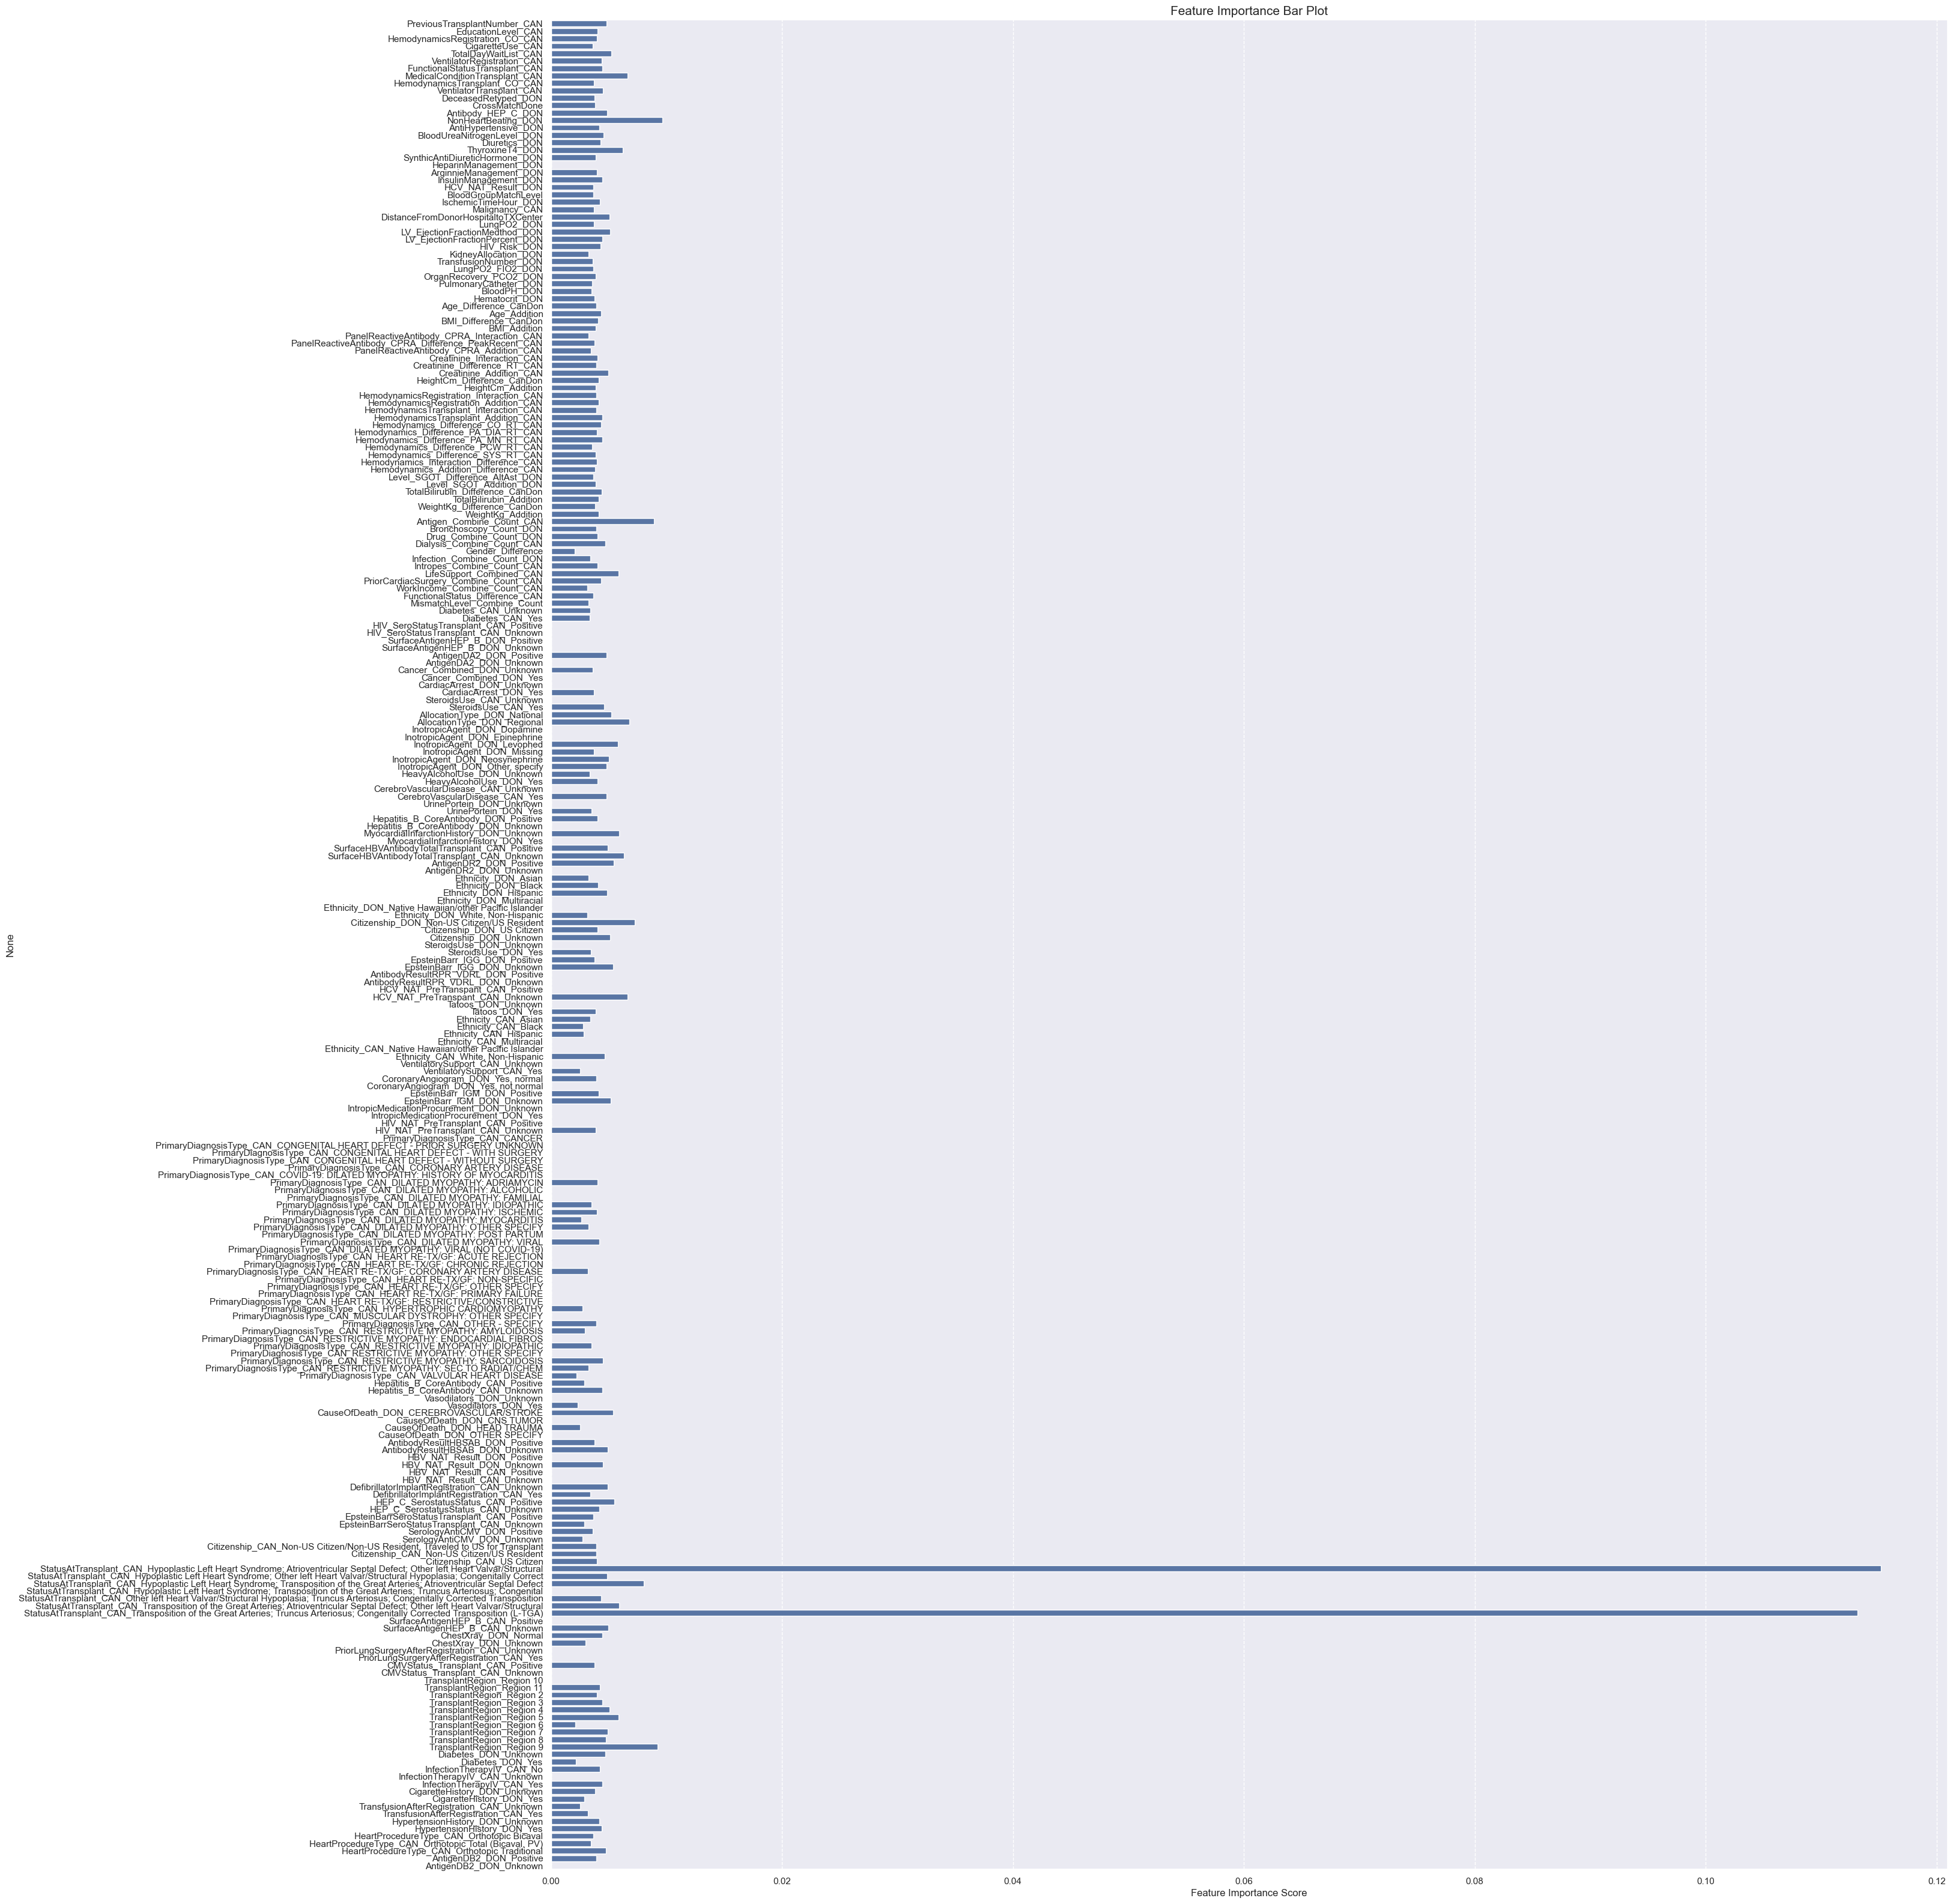

In [20]:
df_xgb = umf.plotFeatureImportance(model, pd.DataFrame(X_train_scale, columns=X_train.columns.to_list()),figsize=(30,40))

In [21]:
df_xgb.sort_values(by='Feature Importance Score', ascending=False).head(10)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.115168
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.113123
NonHeartBeating_DON,0.009627
TransplantRegion_Region 9,0.009209
Antigen_Combine_Count_CAN,0.008924
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.008020
Citizenship_DON_Non-US Citizen/US Resident,0.007242
AllocationType_DON_Regional,0.006791
MedicalConditionTransplant_CAN,0.006650
HCV_NAT_PreTranspant_CAN_Unknown,0.006633


#### Metrics

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.91      0.84      3545
        True       0.92      0.79      0.85      4323

    accuracy                           0.85      7868
   macro avg       0.85      0.85      0.85      7868
weighted avg       0.86      0.85      0.85      7868



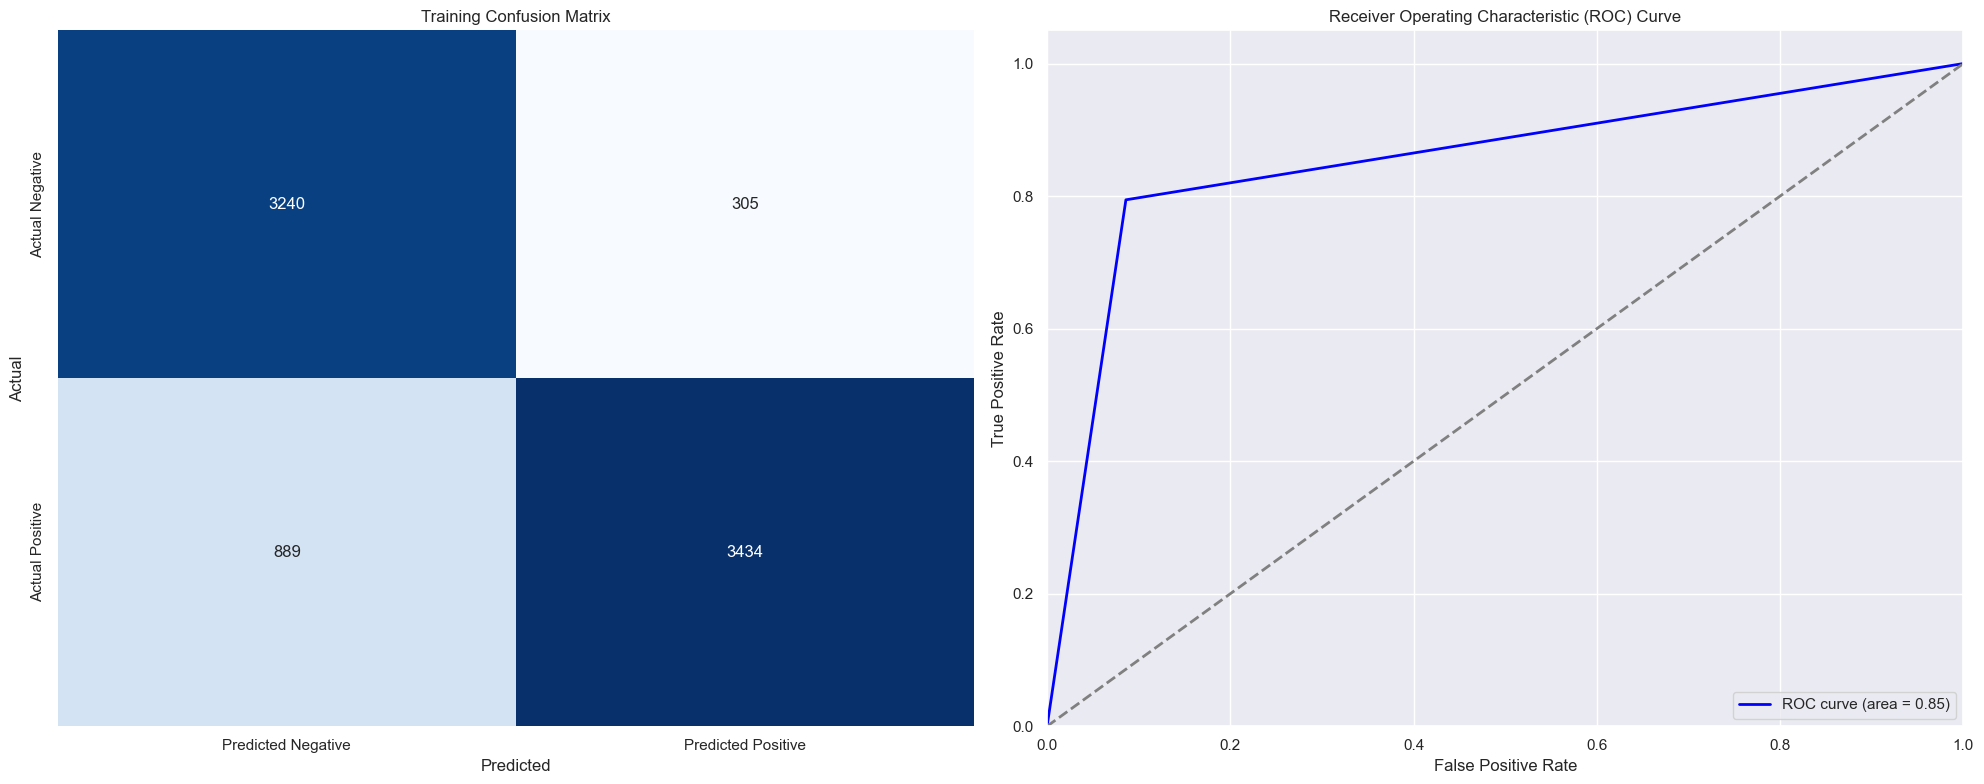

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160


In [22]:
# initialize variables
Algorithm = 'XGBClassifier'
Desc = 'XGBClassifier - Grid Search - All Features'
Model = 'xgb_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.70      0.86      0.77       886
        True       0.86      0.69      0.77      1081

    accuracy                           0.77      1967
   macro avg       0.78      0.78      0.77      1967
weighted avg       0.79      0.77      0.77      1967



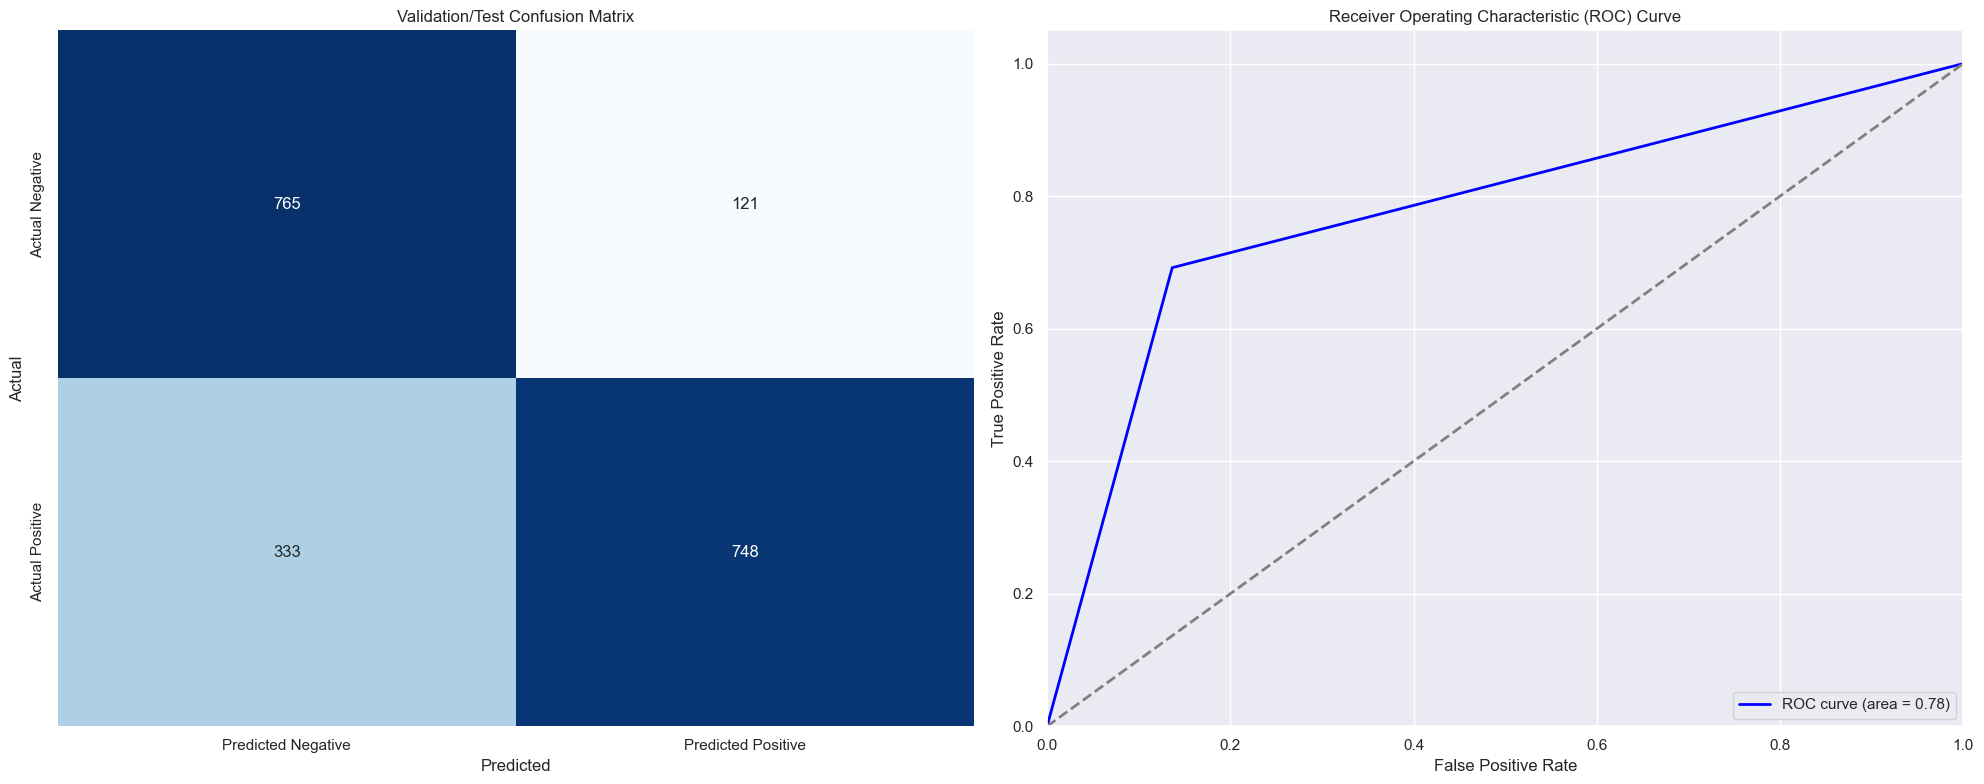

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692


In [23]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### KNN
- `K-Nearest Neighbors (KNN)`
    - Type: Instance-based learning (lazy learning)
    - Mechanism: Classifies a data point based on the majority class among its k-nearest neighbors.
    - Pros: Simple, intuitive, no training phase.
    - Cons: Computationally expensive during prediction, sensitive to irrelevant features and the choice of k.

In [24]:
# import library
from sklearn.neighbors import KNeighborsClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'leaf_size': [10, 30, 50]
}

# create a KNN model
model = KNeighborsClassifier(n_jobs=-1)

# CV with grid search for Hyper-Parameter tuning
knn_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = knn_fit.best_estimator_

CV accuracy: 0.704 +/- 0.011


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [25]:
print(model)

KNeighborsClassifier(leaf_size=10, metric='manhattan', n_jobs=-1, n_neighbors=7)


#### Metrics

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.74      0.76      3545
        True       0.80      0.84      0.82      4323

    accuracy                           0.79      7868
   macro avg       0.79      0.79      0.79      7868
weighted avg       0.79      0.79      0.79      7868



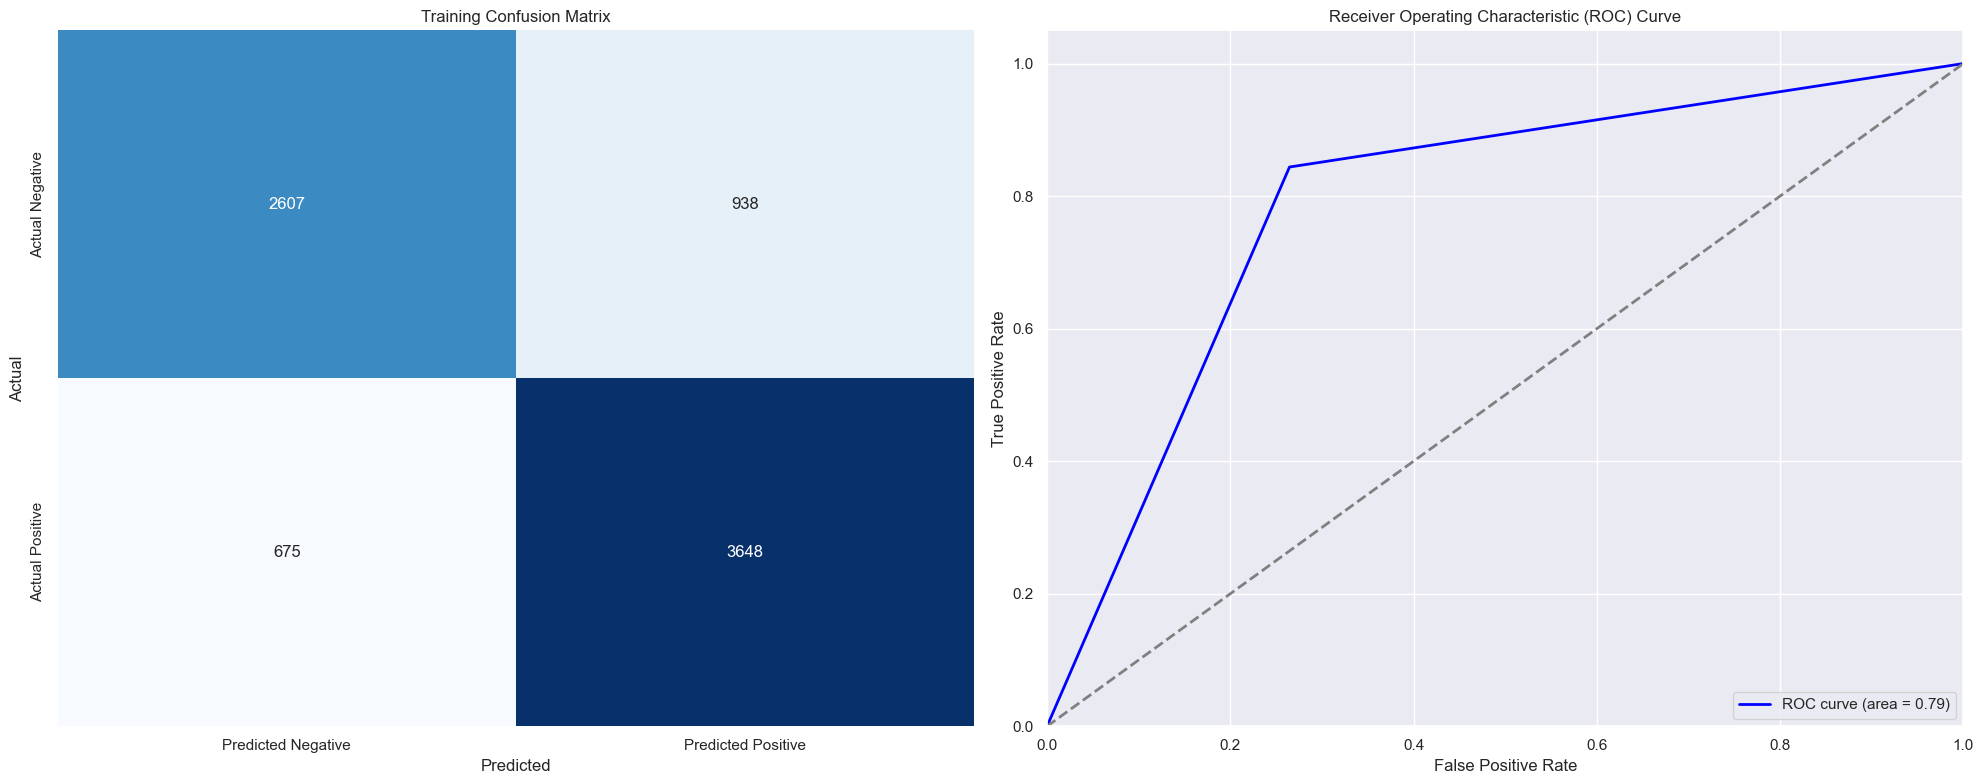

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630


In [26]:
# initialize variables
Algorithm = 'KNN'
Desc = 'KNN - Grid Search - All Features'
Model = 'knn_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.66      0.63      0.65       886
        True       0.71      0.74      0.72      1081

    accuracy                           0.69      1967
   macro avg       0.69      0.69      0.69      1967
weighted avg       0.69      0.69      0.69      1967



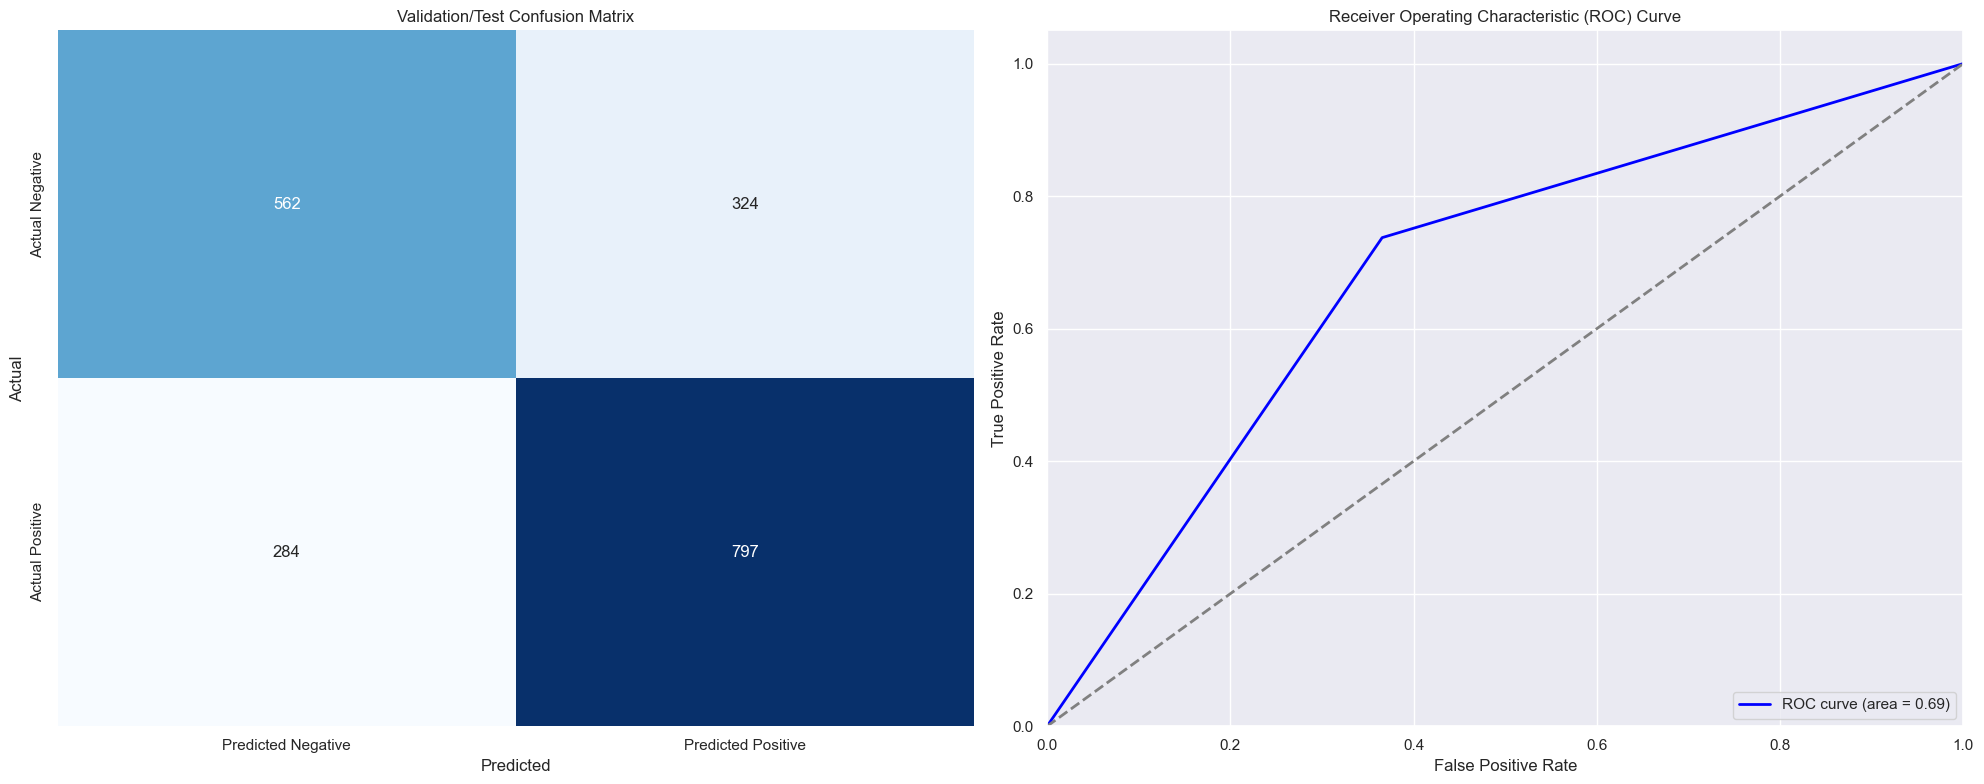

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796


In [27]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### AdaBoost
- `Ada Boost`
  - Type: Adaptive Boosting
  - Mechanism: Sequentially builds weak classifiers (typically decision stumps), where each classifier focuses more on the misclassified samples from the previous ones by adjusting their weights.
  - Pros: Effective at reducing both bias and variance and works well with various base classifiers.
  - Cons: Can be sensitive to noisy data and outliers.

In [28]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 1.0]
}
# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# CV with grid search for Hyper-Parameter tuning
ada_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = ada_fit.best_estimator_

CV accuracy: 0.764 +/- 0.009


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [29]:
print(model)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=200, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.70      0.87      0.77      3545
        True       0.86      0.69      0.77      4323

    accuracy                           0.77      7868
   macro avg       0.78      0.78      0.77      7868
weighted avg       0.79      0.77      0.77      7868



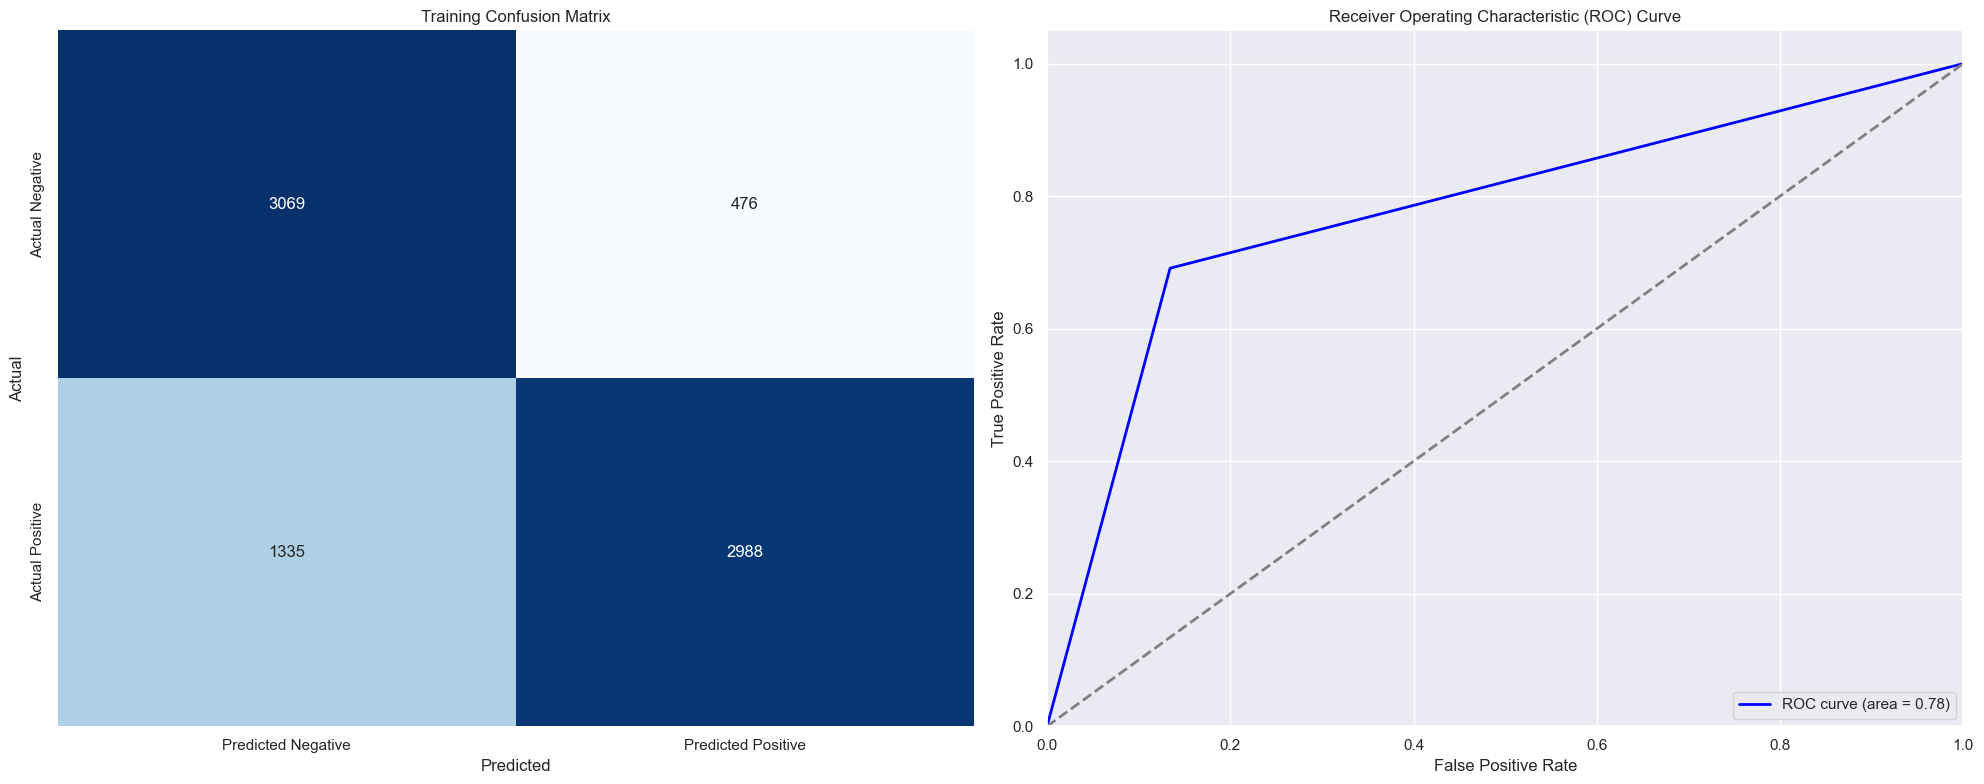

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.769827,0.691187,0.767433,0.765883,0.862587,0.865726,0.778457


In [30]:
# initialize variables
Algorithm = 'AdaBoost'
Desc = 'AdaBoost - Grid Search - All Features'
Model = 'ada_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.69      0.87      0.77       886
        True       0.86      0.68      0.76      1081

    accuracy                           0.76      1967
   macro avg       0.78      0.77      0.76      1967
weighted avg       0.79      0.76      0.76      1967



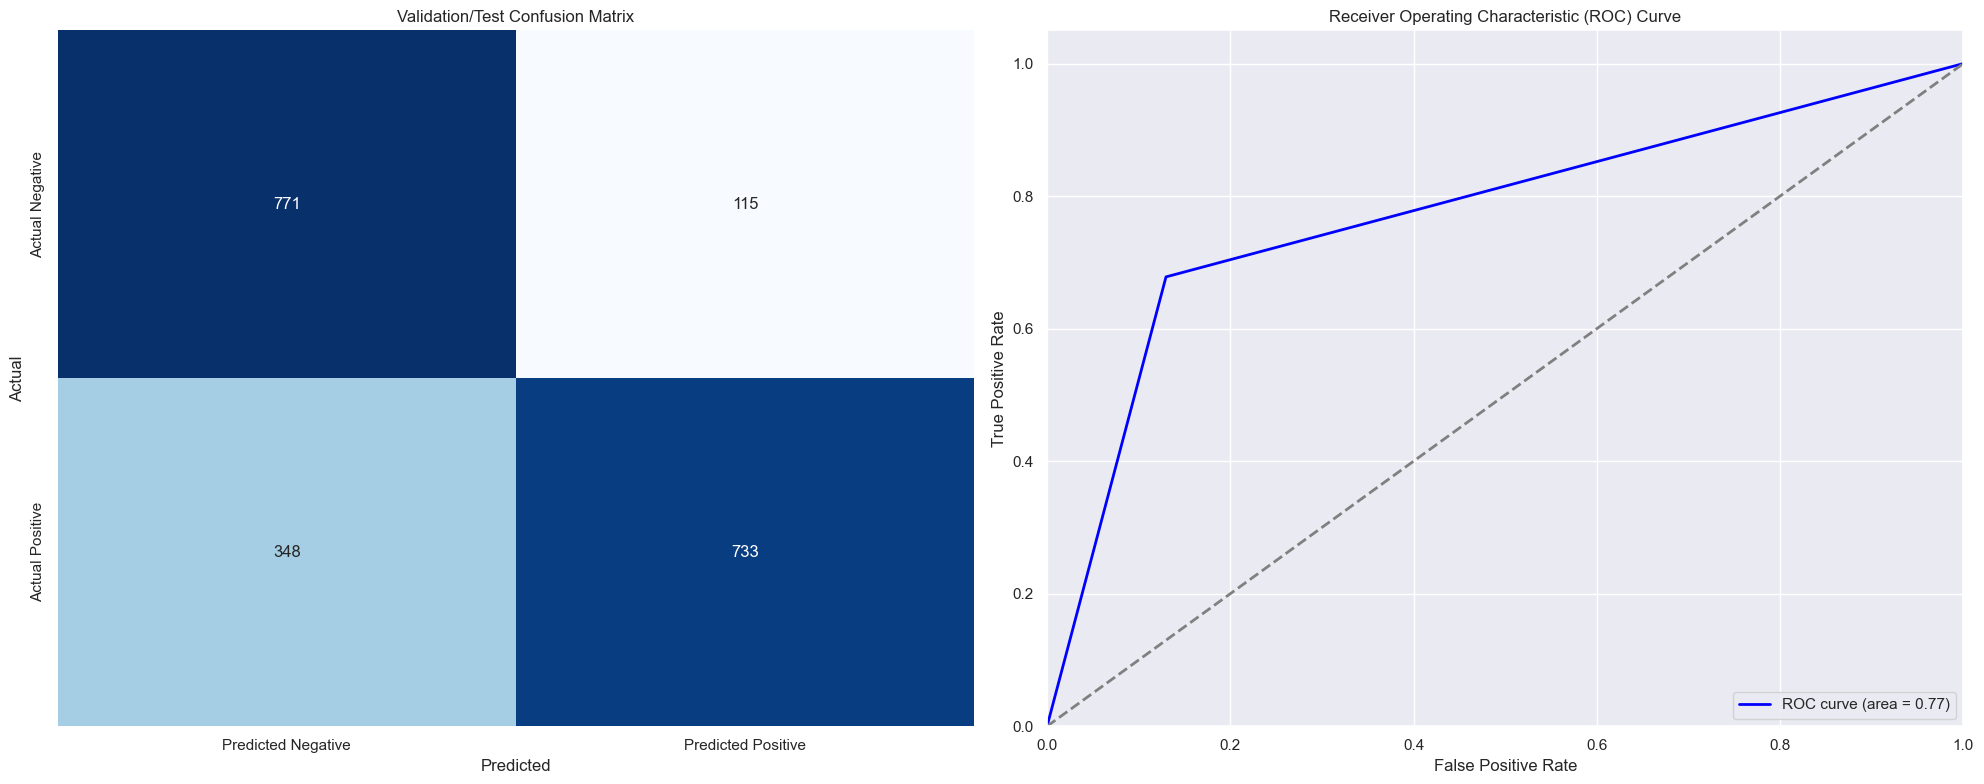

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.769827,0.691187,0.767433,0.765883,0.862587,0.865726,0.778457
9,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Validation/test,0.764616,0.678076,0.759979,0.763039,0.864387,0.870203,0.774140


In [31]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### FAMD (Factor Analysis of Mixed Data) 

PreviousTransplantNumber_CAN                                                                                                      float64
EducationLevel_CAN                                                                                                                float64
HemodynamicsRegistration_CO_CAN                                                                                                   float64
CigaretteUse_CAN                                                                                                                  float64
TotalDayWaitList_CAN                                                                                                              float64
VentilatorRegistration_CAN                                                                                                        float64
FunctionalStatusTransplant_CAN                                                                                                    float64
MedicalConditionTransplant_CAN    

In [33]:
# create scale into dataframe
data = pd.DataFrame(X_train_scale, columns=X_train.columns.to_list())

In [34]:
# import library
from prince import FAMD

# Initialize FAMD
famd = FAMD(
    n_components=2,             # Number of dimensions to keep
    n_iter=10,                  # Number of iterations for the SVD algorithm
    random_state=RANDOM_STATE   # For reproducibility
)

# Fit the model and transform the data
famd_results = famd.fit_transform(data)
 
# Get the explained inertia ratio
explained_inertia = famd.explained_inertia_ratio_

# Plot the results
fig, ax = plt.subplots(figsize=(10, 8))
famd.plot_row_coordinates(
    data,
    ax=ax,
    show_column_labels=True
)
plt.title('FAMD - First Two Dimensions')
plt.show()

# Print explained variance
print("Explained inertia ratio:", explained_inertia)

# Access transformed data
transformed_data = famd_results.values

# Access factor loadings
factor_loadings = famd.column_correlations_

# Print factor loadings
print("Factor Loadings:")
print(factor_loadings)

ValueError: All variables are quantitative: PCA should be used

### Select K Best

In [65]:
# get all the features
seleckKbest = selectKClassif(X_test, y_test, K='all', function='f_classif')

# select p-value > 0.01
seleckKbest = seleckKbest.Feature[seleckKbest.p_value <= 0.05].to_list()

# display
print(f"Total Selected Features: {len(seleckKbest)}")

Total Selected Features: 57


In [66]:
# initialize MinMaxScaler
scale = MinMaxScaler(feature_range=(1, 10))

# fit
fitScale = scale.fit(X_train[seleckKbest])

# transform
X_train_scale = fitScale.transform(X_train[seleckKbest])
X_test_scale = fitScale.transform(X_test[seleckKbest])

### RandomForestClassifier
- Select K Best: p_value <= 0.05

In [67]:
# grid search Hyperparameters Random Forest Classfiier
parameters = {
    'n_estimators': [100, 300, 500],
    'min_samples_split': [30, 40, 50],
    'min_samples_leaf': [8, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 7]
}

# Initialize Model with class weights
rfc_param = {'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
model = RandomForestClassifier(**rfc_param)

# CV with grid search for Hyper-Parameter tuning
rfc_sk_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score = 'accuracy')

# best model
model = rfc_sk_fit.best_estimator_

CV accuracy: 0.768 +/- 0.009


In [ ]:
print(model)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.70      0.87      0.78      3545
        True       0.87      0.69      0.77      4323

    accuracy                           0.77      7868
   macro avg       0.78      0.78      0.77      7868
weighted avg       0.79      0.77      0.77      7868



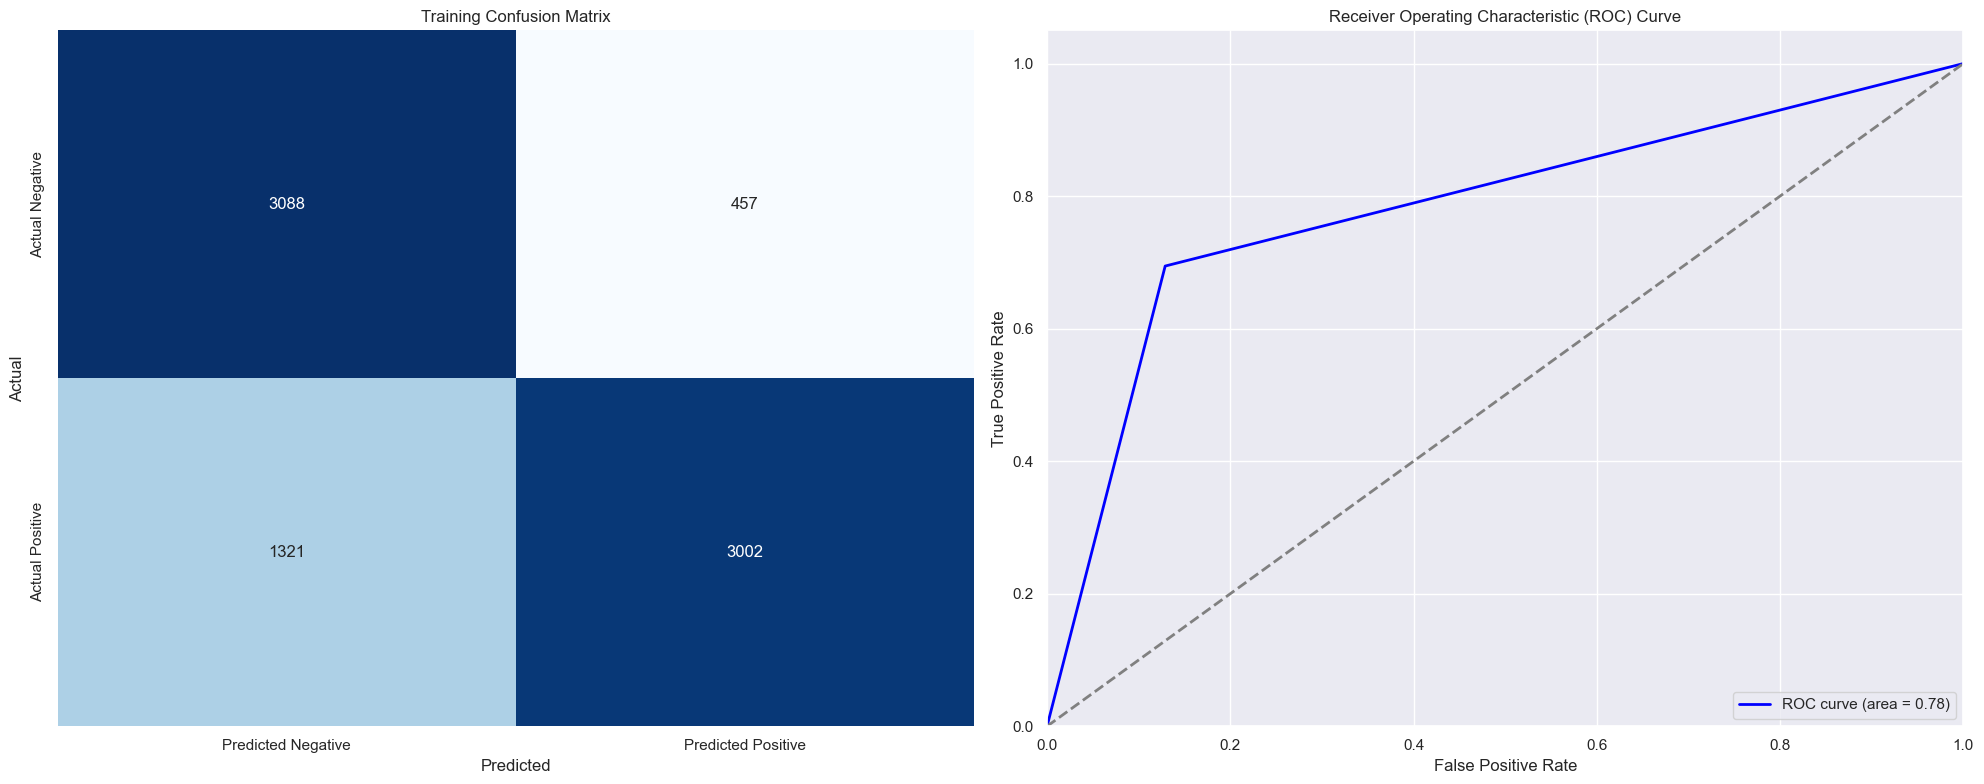

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.769827,0.691187,0.767433,0.765883,0.862587,0.865726,0.778457
9,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Validation/test,0.764616,0.678076,0.759979,0.763039,0.864387,0.870203,0.774140


In [68]:
# initialize variables
Algorithm = 'RandomForestClassifier'
Desc = 'RandomForestClassifier-SelectKBest - Grid Search - All Features p_value <= 0.05'
Model = 'rfc_sk_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.69      0.88      0.77       886
        True       0.87      0.67      0.76      1081

    accuracy                           0.76      1967
   macro avg       0.78      0.77      0.76      1967
weighted avg       0.79      0.76      0.76      1967



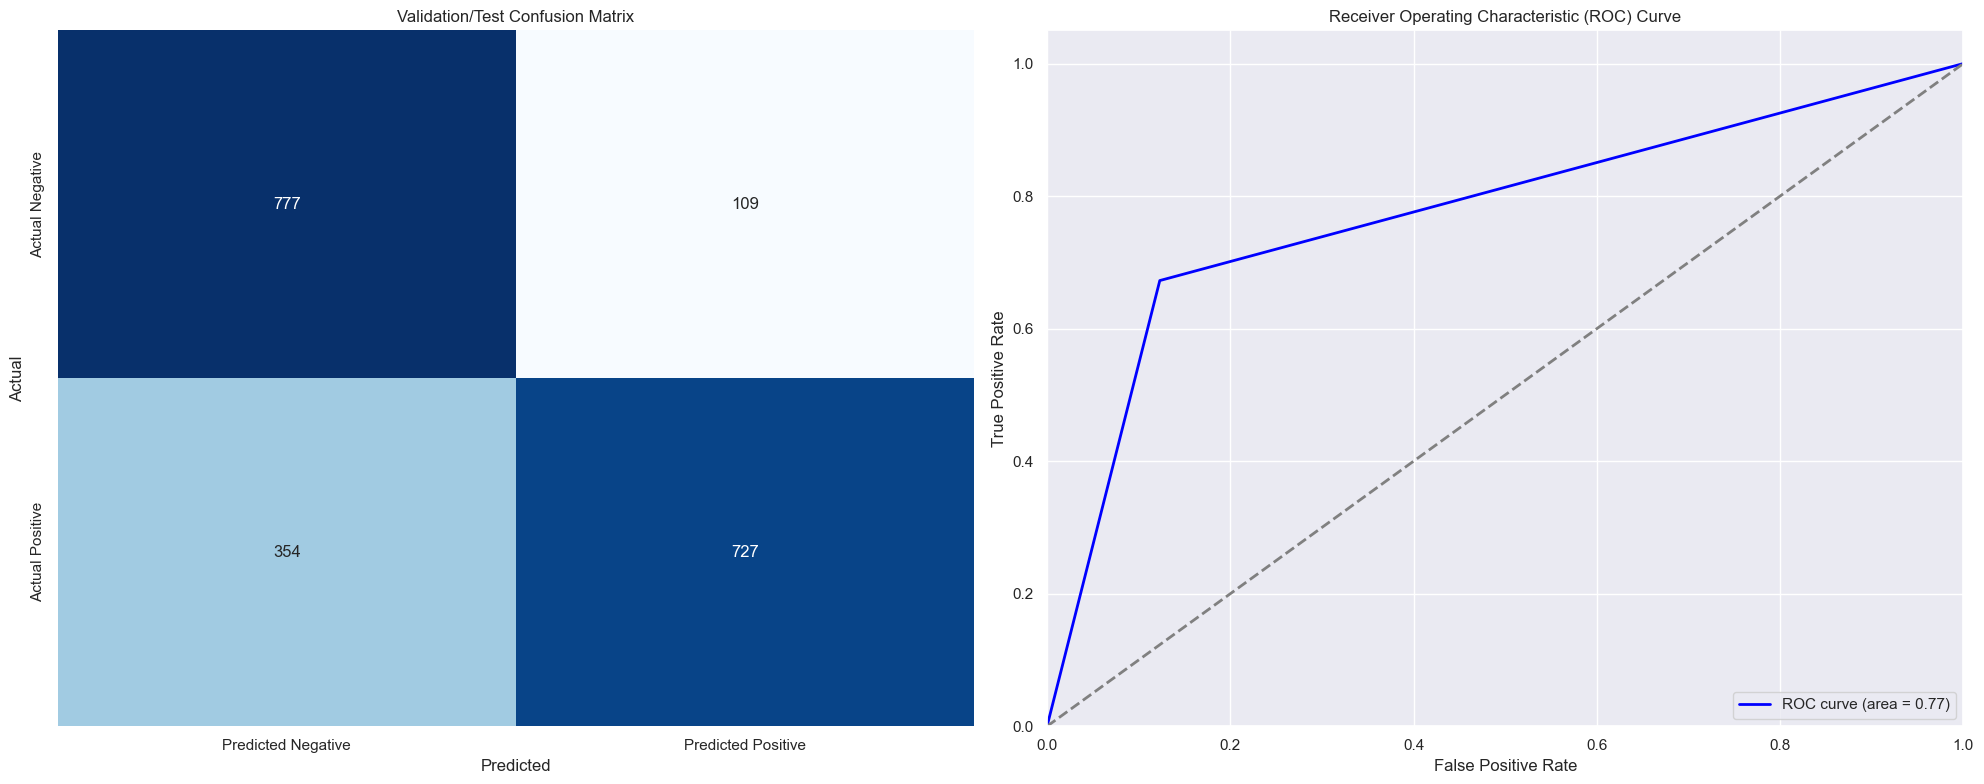

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.769827,0.691187,0.767433,0.765883,0.862587,0.865726,0.778457
9,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Validation/test,0.764616,0.678076,0.759979,0.763039,0.864387,0.870203,0.774140


In [69]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### LogisticRegression

In [70]:
# define the hyperparameter grid to search
parameters = dict(
C = list(np.round(np.linspace(0.01, 5, 20),2))
)

# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate LogisticRegression Classifier
model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
lrc_sk_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = lrc_sk_fit.best_estimator_

CV accuracy: 0.768 +/- 0.008


In [71]:
print(model)

LogisticRegression(C=0.01,
                   class_weight={False: 1.109732016925247,
                                 True: 0.9100161924589405},
                   max_iter=10000, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.69      0.88      0.78      3545
        True       0.88      0.68      0.76      4323

    accuracy                           0.77      7868
   macro avg       0.78      0.78      0.77      7868
weighted avg       0.79      0.77      0.77      7868



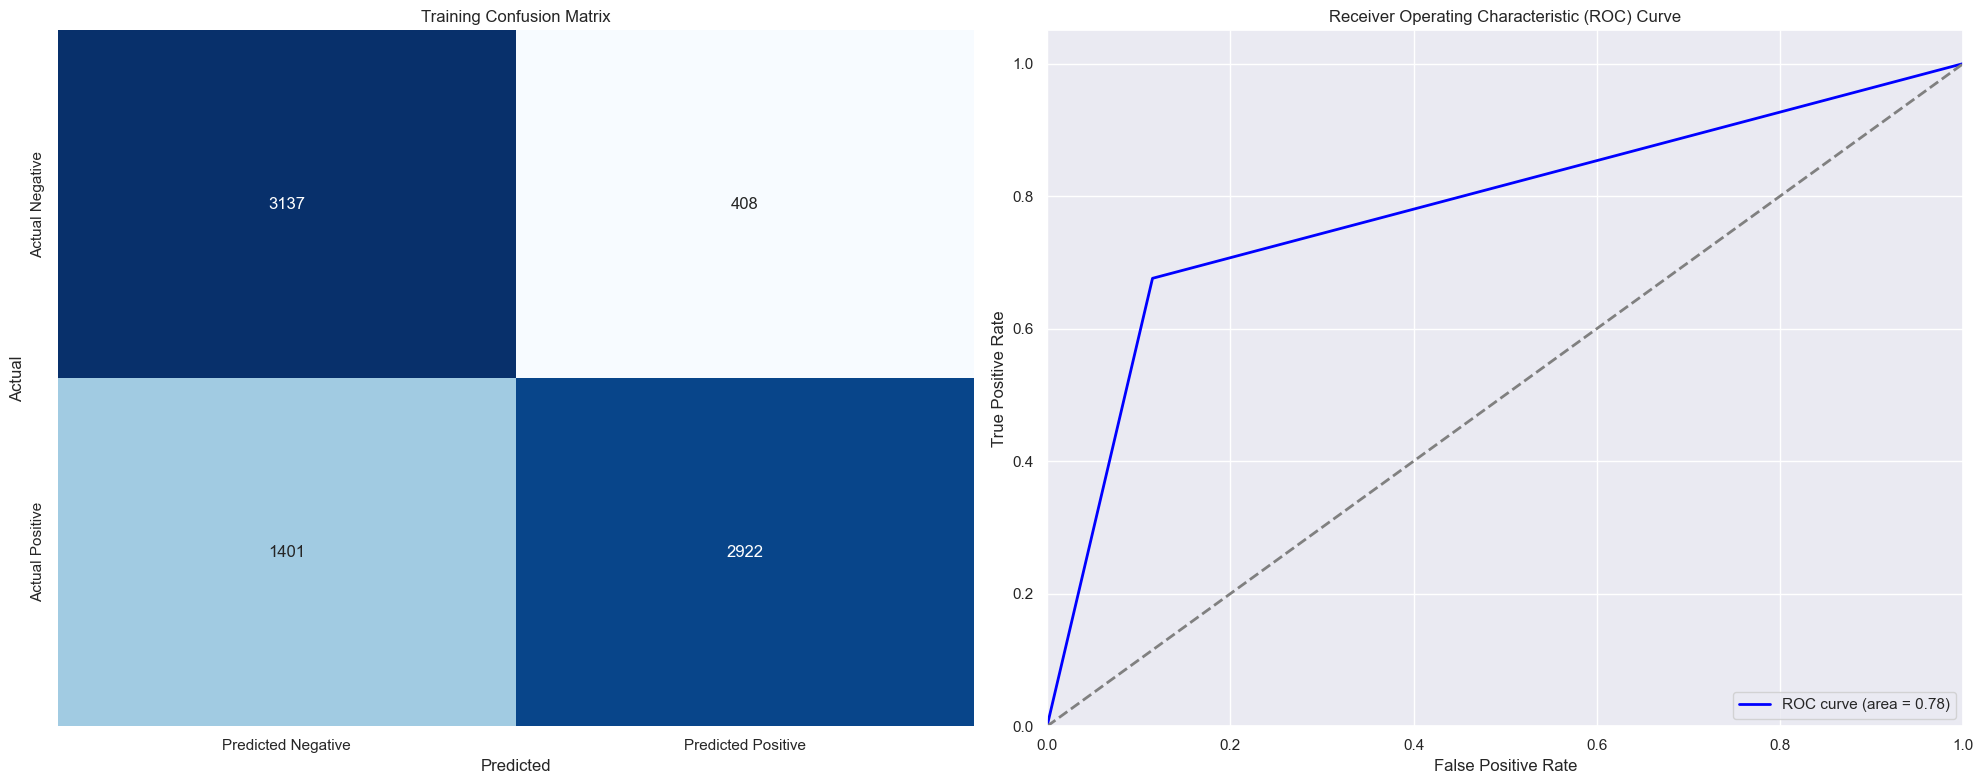

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.769827,0.691187,0.767433,0.765883,0.862587,0.865726,0.778457
9,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Validation/test,0.764616,0.678076,0.759979,0.763039,0.864387,0.870203,0.774140


In [72]:
# initialize variables
Algorithm = 'LogisticRegression'
Desc = 'LogisticRegression-SelectKBest - Grid Search - All Features p_value <= 0.05'
Model = 'lrc_sk_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.68      0.89      0.77       886
        True       0.88      0.66      0.76      1081

    accuracy                           0.77      1967
   macro avg       0.78      0.78      0.76      1967
weighted avg       0.79      0.77      0.76      1967



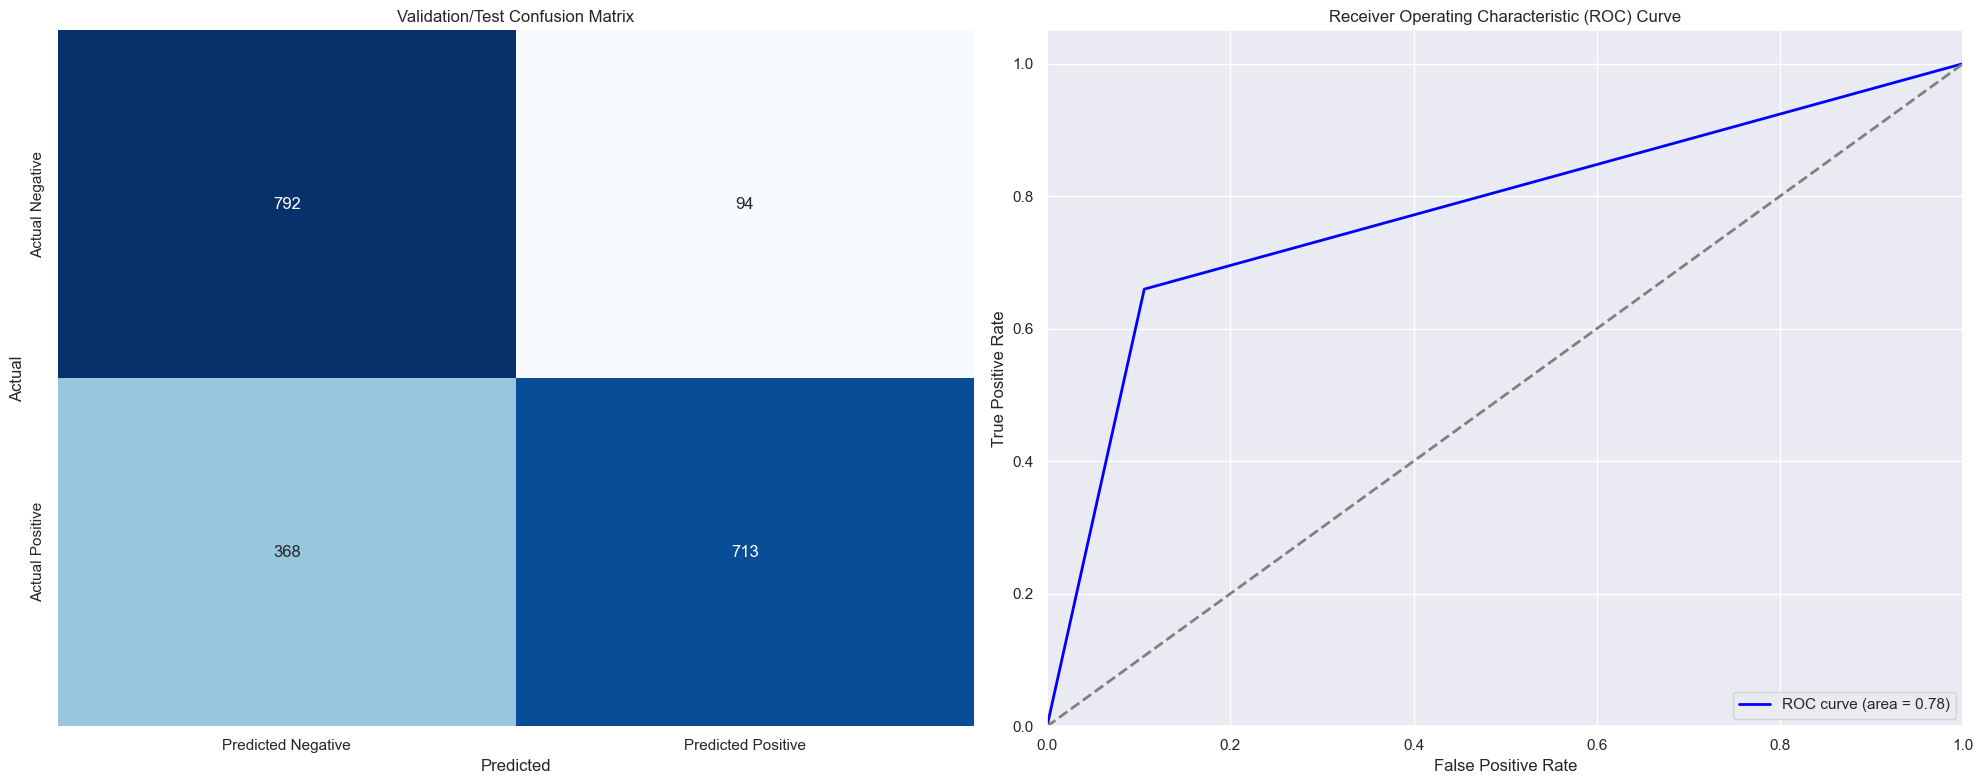

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Training,0.785587,0.715938,0.785832,0.779550,0.870850,0.870522,0.793230
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - All Features,Validation/test,0.766141,0.686401,0.763374,0.762506,0.859791,0.863431,0.774916
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Training,0.783808,0.720102,0.785417,0.775784,0.863762,0.861495,0.790798
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - All Features,Validation/test,0.762074,0.689177,0.760981,0.756265,0.849487,0.851016,0.770096
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Training,0.848246,0.794356,0.851898,0.842547,0.918427,0.913963,0.854160
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - All Features,Validation/test,0.769192,0.691952,0.767179,0.764898,0.860759,0.863431,0.777692
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.794992,0.843858,0.818947,0.757050,0.795464,0.735402,0.789630
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.690900,0.737280,0.723887,0.668568,0.710972,0.634312,0.685796
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.769827,0.691187,0.767433,0.765883,0.862587,0.865726,0.778457
9,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Validation/test,0.764616,0.678076,0.759979,0.763039,0.864387,0.870203,0.774140


In [73]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### XGBClassifier

In [ ]:
# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the hyperparameter grid to search
parameters = dict(
n_estimators = [50, 100, 200],
max_depth = [3, 5],
learning_rate = [0.01, 0.05, 0.1],
subsample = [0.4, 0.7],
gamma = [0.8, 1, 5]   # regularization term that controls the minimum loss reduction required to make a split at a node.
)

# Base Model
xgb_param = {'scale_pos_weight': scale_pos_weight, 'n_jobs': -1, 'random_state': RANDOM_STATE}

# instantiate XGB Classifier
model = XGBClassifier(**xgb_param)

# CV with grid search for Hyper-Parameter tuning
xgb_sk_fit = umf.stratified_grid(model, parameters, X_train_scale, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = xgb_sk_fit.best_estimator_

In [ ]:
print(model)

#### Train

In [ ]:
# initialize variables
Algorithm = 'XGBClassifier'
Desc = 'XGBClassifier-SelectKBest - Grid Search - All Features p_value <= 0.05'
Model = 'xgb_sk_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train_scale, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

In [ ]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test_scale, y_test, Type, metricDF=df_classfication)
df_classfication

### User Function

In [ ]:
def LogisticFeatureImportance(model, figsize=(8,10), fontsize=8):
    """
    This function analyzes the importance of features in a logistic regression model by processing its 
    coefficients. It creates a DataFrame with each feature's name, coefficient, effect description, 
    odds ratio, percentage change in odds, and probability, including a horizontal bar plot of feature importance.
    
    Args:
    - model: Trained logistic regression model (e.g., from sklearn).
    - figsize: Tuple defining the figure size for the plot (default: (8, 10)).
    - fontsize: Font size for axis labels and title (default: 8).
    
    Returns:
    - DataFrame: A DataFrame with feature importance details.
    """
    # Check if the model has been fitted and has the coef_ attribute
    if not hasattr(model, 'coef_'):
        raise ValueError("The model must be a fitted logistic regression model.")
    
    # Get feature names and coefficients
    feature_names = model.feature_names_in_
    coefficients = model.coef_
    
    # If it's a multi-class logistic regression, handle each class separately
    if coefficients.ndim > 1:
        coeff_list = []
        for i in range(coefficients.shape[0]):
            class_name = f"Class {i}"
            class_coefficients = coefficients[i]
            coeff_list.append(pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': class_coefficients,
                'Description': ['Decrease in the log-odds of the Positive Class' if x < 0 else 'Increase in the log-odds of the Positive Class' for x in class_coefficients],
                'Odd Ratio': np.exp(class_coefficients),
                'Percentage Change in Odds': (np.exp(class_coefficients) - 1) * 100,
                'Probability': np.exp(class_coefficients) / (1 + np.exp(class_coefficients)),
                'Class': class_name
            }))
        # Concatenate dataframes for all classes
        LRcoeff_df = pd.concat(coeff_list, ignore_index=True)
    else:
        # Single class logistic regression
        LRcoeff_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients[0],
            'Description': ['Decrease in the log-odds of the Positive Class' if x < 0 else 'Increase in the log-odds of the Positive Class' for x in coefficients[0]],
            'Odd Ratio': np.exp(coefficients[0]),
            'Percentage Change in Odds': (np.exp(coefficients[0]) - 1) * 100,
            'Probability': np.exp(coefficients[0]) / (1 + np.exp(coefficients[0])),
        })
    
    # Sort by Coefficient for better visualization
    LRcoeff_df = LRcoeff_df.sort_values(by='Coefficient', ascending=False)
    
    # Reset the index
    LRcoeff_df.reset_index(drop=True, inplace=True)
    
    # Plot feature importance (using Odds Ratio for better interpretability)
    plt.figure(figsize=figsize)
    if 'Class' in LRcoeff_df.columns:
        # Plot for multi-class case
        for class_name in LRcoeff_df['Class'].unique():
            class_df = LRcoeff_df[LRcoeff_df['Class'] == class_name]
            plt.barh(class_df['Feature'], class_df['Odd Ratio'], label=class_name)
    else:
        # Single class logistic regression
        plt.barh(LRcoeff_df['Feature'], LRcoeff_df['Odd Ratio'], color='steelblue')
    
    plt.axvline(1, color='red', linestyle='--', label="Odd Ratio = 1 (No Effect)")
    plt.xlabel("Odds Ratio")
    plt.ylabel("Features")
    plt.title("Feature Importance in Logistic Regression")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return LRcoeff_df
